In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Path where all stock CSV files are stored
DATA_FOLDER = "../data/processed"

# Folder where trained GRU models will be saved
MODEL_FOLDER = "../models/gru_models"

# Folder where training results will be saved
RESULTS_FOLDER = "../results"

# Create folders if they don't exist
os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(RESULTS_FOLDER, exist_ok=True)

print("Data folder:", DATA_FOLDER)
print("Model folder:", MODEL_FOLDER)
print("Results folder:", RESULTS_FOLDER)

Data folder: ../data/processed
Model folder: ../models/gru_models
Results folder: ../results


In [3]:
# Find all CSV files inside the data folder
csv_files = glob.glob(os.path.join(DATA_FOLDER, "*.csv"))

print("Number of CSV files found:", len(csv_files))
print("\nFirst 10 files:")

for file in csv_files[:10]:
    print(os.path.basename(file))

Number of CSV files found: 10

First 10 files:
AXISBANK.csv
BHARTIARTL.csv
HDFCBANK.csv
ICICIBANK.csv
INFY.csv
ITC.csv
LT.csv
RELIANCE.csv
SBIN.csv
TCS.csv


In [4]:
# GRU Configuration

LOOKBACK = 60
TRAIN_RATIO = 0.80

EPOCHS = 50
BATCH_SIZE = 32

VALIDATION_SPLIT = 0.10

print("GRU Training Configuration")
print("-" * 40)
print("Lookback window:", LOOKBACK)
print("Train/Test split:", TRAIN_RATIO)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Validation split:", VALIDATION_SPLIT)

GRU Training Configuration
----------------------------------------
Lookback window: 60
Train/Test split: 0.8
Epochs: 50
Batch size: 32
Validation split: 0.1


In [5]:
def clean_stock_data(file_path):

    # Load CSV
    df = pd.read_csv(file_path)

    # Remove invalid rows
    df = df.dropna(subset=["Date"])

    # Convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # Columns that should be numeric
    numeric_columns = [
        "Adj Close",
        "Close",
        "High",
        "Low",
        "Open",
        "Volume"
    ]

    # Convert to numeric
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Remove rows without Close price
    df = df.dropna(subset=["Close"])

    # Sort chronologically
    df = df.sort_values("Date").reset_index(drop=True)

    return df

In [6]:
acc_path = os.path.join(DATA_FOLDER, "ACC.csv")

acc_df = clean_stock_data(acc_path)

print("Shape:", acc_df.shape)
print()
display(acc_df.head())

print()
print("Date range:")
print("Start:", acc_df["Date"].min())
print("End:", acc_df["Date"].max())

Shape: (2879, 7)



,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-01,1236.871338,1403.550049,1411.000000,1397.949951,1400.150024,101070
1,2015-01-02,1256.567139,1425.900024,1431.000000,1405.550049,1406.400024,153349
2,2015-01-05,1263.396851,1433.650024,1439.750000,1423.750000,1425.000000,207979
3,2015-01-06,1219.246216,1383.550049,1428.949951,1370.550049,1425.000000,368755
4,2015-01-07,1205.058228,1367.449951,1384.949951,1336.199951,1382.000000,301895



Date range:
Start: 2015-01-01 00:00:00
End: 2026-08-25 00:00:00


In [8]:
import os
import pandas as pd

# Project paths
PROCESSED_DATA_DIR = "../data/processed"
MODEL_DIR = "../models/gru_models"
RESULTS_DIR = "../results"

# Create folders if they don't exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Processed data:", PROCESSED_DATA_DIR)
print("Model folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)

Processed data: ../data/processed
Model folder: ../models/gru_models
Results folder: ../results


In [9]:
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

print("Total CSV files:", len(csv_files))

stock_summary = []

for file in csv_files:
    file_path = os.path.join(PROCESSED_DATA_DIR, file)

    try:
        df = pd.read_csv(file_path)

        stock_summary.append({
            "Stock": file.replace(".csv", ""),
            "Rows": len(df),
            "Start Date": df["Date"].iloc[0],
            "End Date": df["Date"].iloc[-1],
            "Status": "OK"
        })

    except Exception as e:
        stock_summary.append({
            "Stock": file.replace(".csv", ""),
            "Rows": 0,
            "Start Date": None,
            "End Date": None,
            "Status": f"ERROR: {str(e)}"
        })

summary_df = pd.DataFrame(stock_summary)

print("\n===== DATASET SUMMARY =====")
print("Total stocks:", len(summary_df))

print("\nStatus counts:")
print(summary_df["Status"].value_counts())

print("\nFirst 10 stocks:")
print(summary_df.head(10))

Total CSV files: 103

===== DATASET SUMMARY =====
Total stocks: 103

Status counts:
Status
OK    103
Name: count, dtype: int64

First 10 stocks:
        Stock  Rows  Start Date    End Date Status
0         ACC  2880         NaN  2026-08-25     OK
1  ADANIPORTS  2880         NaN  2026-08-25     OK
2  ADANIPOWER  2880         NaN  2026-08-25     OK
3       ALKEM  2639         NaN  2026-08-25     OK
4   AMBUJACEM  2880         NaN  2026-08-25     OK
5    ASHOKLEY  2880         NaN  2026-08-25     OK
6  ASIANPAINT  2879         NaN  2026-08-25     OK
7  AUROPHARMA  2879         NaN  2026-08-25     OK
8    AXISBANK  2878  2015-01-01  2026-08-24     OK
9  BAJAJ-AUTO  2880         NaN  2026-08-25     OK


In [10]:
problem_stocks = summary_df[
    (summary_df["Status"] != "OK") |
    (summary_df["Rows"] < 500)
]

print("Problem stocks:", len(problem_stocks))

problem_stocks

Problem stocks: 0


,Stock,Rows,Start Date,End Date,Status


In [11]:
import os
import pandas as pd

cleaning_results = []

for file in csv_files:
    file_path = os.path.join(PROCESSED_DATA_DIR, file)

    try:
        df = pd.read_csv(file_path)

        original_rows = len(df)

        # Convert Date column properly
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

        # Remove invalid rows (such as Yahoo Finance ticker row)
        df = df.dropna(subset=["Date"])

        # Convert numeric columns
        numeric_cols = ["Adj Close", "Close", "High", "Low", "Open", "Volume"]

        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        # Remove rows with missing Close price
        df = df.dropna(subset=["Close"])

        # Sort by date
        df = df.sort_values("Date")

        # Remove duplicate dates
        df = df.drop_duplicates(subset=["Date"])

        # Reset index
        df = df.reset_index(drop=True)

        # Save cleaned version
        df.to_csv(file_path, index=False)

        cleaning_results.append({
            "Stock": file.replace(".csv", ""),
            "Original Rows": original_rows,
            "Cleaned Rows": len(df),
            "Start Date": df["Date"].iloc[0],
            "End Date": df["Date"].iloc[-1],
            "Status": "OK"
        })

    except Exception as e:
        cleaning_results.append({
            "Stock": file.replace(".csv", ""),
            "Original Rows": original_rows if 'original_rows' in locals() else 0,
            "Cleaned Rows": 0,
            "Start Date": None,
            "End Date": None,
            "Status": f"ERROR: {str(e)}"
        })


cleaning_df = pd.DataFrame(cleaning_results)

print("===== CLEANING COMPLETED =====")
print("\nTotal stocks:", len(cleaning_df))

print("\nStatus:")
print(cleaning_df["Status"].value_counts())

print("\nFirst 10 cleaned datasets:")
print(cleaning_df.head(10))

===== CLEANING COMPLETED =====

Total stocks: 103

Status:
Status
OK    103
Name: count, dtype: int64

First 10 cleaned datasets:
        Stock  Original Rows  Cleaned Rows Start Date   End Date Status
0         ACC           2880          2879 2015-01-01 2026-08-25     OK
1  ADANIPORTS           2880          2879 2015-01-01 2026-08-25     OK
2  ADANIPOWER           2880          2879 2015-01-01 2026-08-25     OK
3       ALKEM           2639          2638 2015-12-23 2026-08-25     OK
4   AMBUJACEM           2880          2879 2015-01-01 2026-08-25     OK
5    ASHOKLEY           2880          2879 2015-01-01 2026-08-25     OK
6  ASIANPAINT           2879          2878 2015-01-01 2026-08-25     OK
7  AUROPHARMA           2879          2878 2015-01-01 2026-08-25     OK
8    AXISBANK           2878          2878 2015-01-01 2026-08-24     OK
9  BAJAJ-AUTO           2880          2879 2015-01-01 2026-08-25     OK


In [12]:
print("\nStocks with missing start dates:")
print(cleaning_df[cleaning_df["Start Date"].isna()])

print("\nStocks with less than 500 records:")
print(cleaning_df[cleaning_df["Cleaned Rows"] < 500])

print("\nMinimum records:", cleaning_df["Cleaned Rows"].min())
print("Maximum records:", cleaning_df["Cleaned Rows"].max())


Stocks with missing start dates:
Empty DataFrame
Columns: [Stock, Original Rows, Cleaned Rows, Start Date, End Date, Status]
Index: []

Stocks with less than 500 records:
Empty DataFrame
Columns: [Stock, Original Rows, Cleaned Rows, Start Date, End Date, Status]
Index: []

Minimum records: 1182
Maximum records: 2879


In [19]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [13]:
# ==========================================
# GRU CONFIGURATION
# ==========================================

LOOKBACK = 60          # Previous 60 trading days
TRAIN_RATIO = 0.80     # 80% training
EPOCHS = 100
BATCH_SIZE = 32

print("Lookback window:", LOOKBACK)
print("Train/Test split:", TRAIN_RATIO)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Lookback window: 60
Train/Test split: 0.8
Epochs: 100
Batch size: 32


In [14]:
def create_sequences(data, lookback=60):

    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

In [15]:
def build_gru_model(lookback):

    model = Sequential([
        GRU(
            64,
            return_sequences=True,
            input_shape=(lookback, 1)
        ),

        Dropout(0.2),

        GRU(32),

        Dropout(0.2),

        Dense(16, activation="relu"),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )

    return model

In [17]:
def train_stock_gru(stock_name, verbose=1):

    print("\n" + "=" * 60)
    print(f"TRAINING GRU MODEL: {stock_name}")
    print("=" * 60)

    # ------------------------------------------
    # 1. Load stock data
    # ------------------------------------------
    file_path = os.path.join(
        PROCESSED_DATA_DIR,
        f"{stock_name}.csv"
    )

    df = pd.read_csv(file_path)

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    prices = df[["Close"]].values.astype(float)

    print(f"Total records: {len(prices)}")
    print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

    # ------------------------------------------
    # 2. Train/Test Split
    # ------------------------------------------
    train_size = int(len(prices) * TRAIN_RATIO)

    train_data = prices[:train_size]
    test_data = prices[train_size:]

    print(f"Training records: {len(train_data)}")
    print(f"Testing records: {len(test_data)}")

    # ------------------------------------------
    # 3. Scale data
    # IMPORTANT: Fit scaler only on training data
    # ------------------------------------------
    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)

    # ------------------------------------------
    # 4. Create training sequences
    # ------------------------------------------
    X_train, y_train = create_sequences(
        train_scaled,
        LOOKBACK
    )

    # ------------------------------------------
    # 5. Create test sequences
    # Add last LOOKBACK training values
    # so first test prediction has context
    # ------------------------------------------
    test_input = np.vstack((
        train_scaled[-LOOKBACK:],
        test_scaled
    ))

    X_test, y_test = create_sequences(
        test_input,
        LOOKBACK
    )

    # ------------------------------------------
    # 6. Reshape for GRU
    # Shape: samples, timesteps, features
    # ------------------------------------------
    X_train = X_train.reshape(
        X_train.shape[0],
        X_train.shape[1],
        1
    )

    X_test = X_test.reshape(
        X_test.shape[0],
        X_test.shape[1],
        1
    )

    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")

    # ------------------------------------------
    # 7. Build GRU model
    # ------------------------------------------
    tf.keras.backend.clear_session()

    model = build_gru_model(LOOKBACK)

    # ------------------------------------------
    # 8. Early stopping
    # ------------------------------------------
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # ------------------------------------------
    # 9. Train model
    # ------------------------------------------
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=verbose
    )

    # ------------------------------------------
    # 10. Predictions
    # ------------------------------------------
    predictions_scaled = model.predict(
        X_test,
        verbose=0
    )

    # Convert back to original prices
    predictions = scaler.inverse_transform(
        predictions_scaled
    )

    actual_prices = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    )

    # ------------------------------------------
    # 11. Calculate metrics
    # ------------------------------------------
    mae = mean_absolute_error(
        actual_prices,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_prices,
            predictions
        )
    )

    mape = mean_absolute_percentage_error(
        actual_prices,
        predictions
    ) * 100

    r2 = r2_score(
        actual_prices,
        predictions
    )

    # ------------------------------------------
    # 12. Save model and scaler
    # ------------------------------------------
    model_path = os.path.join(
        MODEL_DIR,
        f"{stock_name}_gru.keras"
    )

    scaler_path = os.path.join(
        MODEL_DIR,
        f"{stock_name}_scaler.pkl"
    )

    model.save(model_path)
    joblib.dump(scaler, scaler_path)

    # ------------------------------------------
    # 13. Results
    # ------------------------------------------
    result = {
        "Stock": stock_name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "MAPE": round(mape, 4),
        "R2": round(r2, 4),
        "Train Records": len(train_data),
        "Test Records": len(test_data),
        "Model Path": model_path,
        "Scaler Path": scaler_path
    }

    print("\n===== RESULTS =====")
    print(f"MAE: ₹{mae:.2f}")
    print(f"RMSE: ₹{rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R² Score: {r2:.4f}")

    print("\nModel saved:", model_path)
    print("Scaler saved:", scaler_path)

    return result, history, model, predictions, actual_prices, df

In [21]:
import joblib

In [22]:
sbin_result, sbin_history, sbin_model, sbin_predictions, sbin_actual, sbin_df = train_stock_gru(
    "SBIN",
    verbose=1
)


TRAINING GRU MODEL: SBIN
Total records: 2878
Date range: 2015-01-01 to 2026-08-24
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)
Epoch 1/100


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0097 - val_loss: 0.0013
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0011 - val_loss: 0.0057
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 9.9866e-04 - val_loss: 0.0022
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 8.7034e-04 - val_loss: 0.0024
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 8.1796e-04 - val_loss: 0.0024
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 8.2001e-04 - val_loss: 0.0028
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 6.6536e-04 - val_loss: 0.0027
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 6.2315e-04 - val_loss: 0.0017
Epoch 11/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.8228e-04 - val_loss: 5.1639e-04
Epoch 12/100
64/64 ━━━━━━━━━━━━━

In [23]:
test_stocks = ["SBIN", "RELIANCE", "TCS"]

test_results = []

for stock in test_stocks:
    
    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)
    
    try:
        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )
        
        test_results.append(result)
        
        print(f"\n✓ {stock} completed successfully")
        
    except Exception as e:
        print(f"\n✗ ERROR while training {stock}")
        print(e)

print("\n" + "=" * 60)
print("TEST BATCH COMPLETED")
print("=" * 60)


STARTING: SBIN

TRAINING GRU MODEL: SBIN
Total records: 2878
Date range: 2015-01-01 to 2026-08-24
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹24.68
RMSE: ₹32.02
MAPE: 2.60%
R² Score: 0.9288

Model saved: ../models/gru_models\SBIN_gru.keras
Scaler saved: ../models/gru_models\SBIN_scaler.pkl

✓ SBIN completed successfully

STARTING: RELIANCE

TRAINING GRU MODEL: RELIANCE
Total records: 2878
Date range: 2015-01-01 to 2026-08-24
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹24.99
RMSE: ₹31.50
MAPE: 1.78%
R² Score: 0.8995

Model saved: ../models/gru_models\RELIANCE_gru.keras
Scaler saved: ../models/gru_models\RELIANCE_scaler.pkl

✓ RELIANCE completed successfully

STARTING: TCS

TRAINING GRU MODEL: TCS
Total records: 2878
Date range: 2015-01-01 to 2026-08-24
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹54.43
RMSE: ₹70.45
MAPE: 1.69%
R² Score: 0.9899

Model saved: ../models/gru_models\TCS_gru.keras
Scaler saved: ../models/gru_models\TCS_scaler.pkl

✓ TCS completed successfully

TEST BATCH COMPLETED


In [24]:
import os
import pandas as pd
import traceback

# ------------------------------------------
# Get all available stock CSV files
# ------------------------------------------

all_stock_files = sorted([
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
])

all_stocks = [
    os.path.splitext(f)[0]
    for f in all_stock_files
]

print("Total stocks available:", len(all_stocks))

# ------------------------------------------
# Check already trained models
# ------------------------------------------

trained_stocks = []

for stock in all_stocks:
    
    model_path = os.path.join(
        MODEL_DIR,
        f"{stock}_gru.keras"
    )
    
    scaler_path = os.path.join(
        MODEL_DIR,
        f"{stock}_scaler.pkl"
    )
    
    if os.path.exists(model_path) and os.path.exists(scaler_path):
        trained_stocks.append(stock)


stocks_to_train = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Already trained:", len(trained_stocks))
print("Still need training:", len(stocks_to_train))

print("\nAlready trained stocks:")
print(trained_stocks[:20])

print("\nFirst stocks to train:")
print(stocks_to_train[:10])

Total stocks available: 103
Already trained: 3
Still need training: 100

Already trained stocks:
['RELIANCE', 'SBIN', 'TCS']

First stocks to train:
['ACC', 'ADANIPORTS', 'ADANIPOWER', 'ALKEM', 'AMBUJACEM', 'ASHOKLEY', 'ASIANPAINT', 'AUROPHARMA', 'AXISBANK', 'BAJAJ-AUTO']


In [25]:
# Get remaining stocks again

csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = [
    os.path.splitext(f)[0]
    for f in csv_files
]

trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select first batch of 10
batch_stocks = remaining_stocks[:10]

print("\nSTOCKS IN THIS BATCH:")
print(batch_stocks)

Total stocks: 103
Already trained: 3
Remaining: 100

STOCKS IN THIS BATCH:
['ACC', 'ADANIPORTS', 'ADANIPOWER', 'ALKEM', 'AMBUJACEM', 'ASHOKLEY', 'ASIANPAINT', 'AUROPHARMA', 'AXISBANK', 'BAJAJ-AUTO']


In [26]:
batch_results = []

for stock in batch_stocks:

    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)

    try:

        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )

        batch_results.append(result)

        print(f"\n✓ {stock} COMPLETED SUCCESSFULLY")

    except Exception as e:

        print(f"\n✗ ERROR TRAINING {stock}")
        print(e)

print("\n" + "=" * 60)
print("BATCH COMPLETED")
print("=" * 60)


STARTING: ACC

TRAINING GRU MODEL: ACC
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹32.65
RMSE: ₹43.49
MAPE: 1.75%
R² Score: 0.9871

Model saved: ../models/gru_models\ACC_gru.keras
Scaler saved: ../models/gru_models\ACC_scaler.pkl

✓ ACC COMPLETED SUCCESSFULLY

STARTING: ADANIPORTS

TRAINING GRU MODEL: ADANIPORTS
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹38.33
RMSE: ₹48.91
MAPE: 2.57%
R² Score: 0.9322

Model saved: ../models/gru_models\ADANIPORTS_gru.keras
Scaler saved: ../models/gru_models\ADANIPORTS_scaler.pkl

✓ ADANIPORTS COMPLETED SUCCESSFULLY

STARTING: ADANIPOWER

TRAINING GRU MODEL: ADANIPOWER
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


...


===== RESULTS =====
MAE: ₹20.69
RMSE: ₹26.69
MAPE: 1.60%
R² Score: 0.9729

Model saved: ../models/gru_models\AUROPHARMA_gru.keras
Scaler saved: ../models/gru_models\AUROPHARMA_scaler.pkl

✓ AUROPHARMA COMPLETED SUCCESSFULLY

STARTING: AXISBANK

TRAINING GRU MODEL: AXISBANK
Total records: 2878
Date range: 2015-01-01 to 2026-08-24
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹27.02
RMSE: ₹34.12
MAPE: 2.22%
R² Score: 0.8786

Model saved: ../models/gru_models\AXISBANK_gru.keras
Scaler saved: ../models/gru_models\AXISBANK_scaler.pkl

✓ AXISBANK COMPLETED SUCCESSFULLY

STARTING: BAJAJ-AUTO

TRAINING GRU MODEL: BAJAJ-AUTO
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹114.94
RMSE: ₹161.27
MAPE: 1.23%
R² Score: 0.9758

Model saved: ../models/gru_models\BAJAJ-AUTO_gru.keras
Scaler saved: ../models/gru_models\BAJAJ-AUTO_scaler.pkl

✓ BAJAJ-AUTO COMPLETED SUCCESSFULLY

BATCH COMPLETED


In [27]:
batch_results_df = pd.DataFrame(batch_results)

batch_results_df

,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,ACC,32.6485,43.4870,1.7532,0.9871,2303,576,../models/gru_models\ACC_gru.keras,../models/gru_models\ACC_scaler.pkl
1,ADANIPORTS,38.3302,48.9104,2.5739,0.9322,2303,576,../models/gru_models\ADANIPORTS_gru.keras,../models/gru_models\ADANIPORTS_scaler.pkl
2,ADANIPOWER,6.7120,10.3779,4.0563,0.9276,2303,576,../models/gru_models\ADANIPOWER_gru.keras,../models/gru_models\ADANIPOWER_scaler.pkl
3,ALKEM,65.2207,86.7112,1.1994,0.9461,2110,528,../models/gru_models\ALKEM_gru.keras,../models/gru_models\ALKEM_scaler.pkl
4,AMBUJACEM,10.6584,14.1322,2.0073,0.9605,2303,576,../models/gru_models\AMBUJACEM_gru.keras,../models/gru_models\AMBUJACEM_scaler.pkl
5,ASHOKLEY,4.5650,6.3718,3.0709,0.9505,2303,576,../models/gru_models\ASHOKLEY_gru.keras,../models/gru_models\ASHOKLEY_scaler.pkl
6,ASIANPAINT,50.9841,67.5730,1.9987,0.9473,2302,576,../models/gru_models\ASIANPAINT_gru.keras,../models/gru_models\ASIANPAINT_scaler.pkl
7,AUROPHARMA,20.6949,26.6922,1.6041,0.9729,2302,576,../models/gru_models\AUROPHARMA_gru.keras,../models/gru_models\AUROPHARMA_scaler.pkl
8,AXISBANK,27.0168,34.1181,2.2236,0.8786,2302,576,../models/gru_models\AXISBANK_gru.keras,../models/gru_models\AXISBANK_scaler.pkl
9,BAJAJ-AUTO,114.9371,161.2747,1.2269,0.9758,2303,576,../models/gru_models\BAJAJ-AUTO_gru.keras,../models/gru_models\BAJAJ-AUTO_scaler.pkl


In [29]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_1_results.csv"),
    index=False
)

print("✓ Batch 1 results saved successfully!")

✓ Batch 1 results saved successfully!


In [30]:
# Get all available stocks
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Find already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Find remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Next batch of 10
batch_stocks = remaining_stocks[:10]

print("\n===== BATCH 2 STOCKS =====")
for i, stock in enumerate(batch_stocks, start=1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 13
Remaining: 90

===== BATCH 2 STOCKS =====
1. BAJAJFINSV
2. BAJFINANCE
3. BALKRISIND
4. BANKBARODA
5. BHARTIARTL
6. BHEL
7. BIOCON
8. BOSCHLTD
9. BPCL
10. BRITANNIA


In [31]:
batch_results = []

for stock in batch_stocks:

    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)

    try:
        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )

        batch_results.append(result)

        print(f"\n✓ {stock} COMPLETED SUCCESSFULLY")

    except Exception as e:
        print(f"\n✗ ERROR TRAINING {stock}")
        print(f"Error: {e}")

print("\n" + "=" * 60)
print("BATCH 2 COMPLETED")
print("=" * 60)


STARTING: BAJAJFINSV

TRAINING GRU MODEL: BAJAJFINSV
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹35.08
RMSE: ₹45.72
MAPE: 1.89%
R² Score: 0.9296

Model saved: ../models/gru_models\BAJAJFINSV_gru.keras
Scaler saved: ../models/gru_models\BAJAJFINSV_scaler.pkl

✓ BAJAJFINSV COMPLETED SUCCESSFULLY

STARTING: BAJFINANCE

TRAINING GRU MODEL: BAJFINANCE
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹18.81
RMSE: ₹24.33
MAPE: 2.11%
R² Score: 0.9659

Model saved: ../models/gru_models\BAJFINANCE_gru.keras
Scaler saved: ../models/gru_models\BAJFINANCE_scaler.pkl

✓ BAJFINANCE COMPLETED SUCCESSFULLY

STARTING: BALKRISIND

TRAINING GRU MODEL: BALKRISIND
Total records: 2877
Date range: 2015-01-01 to 2026-08-25
Training records: 2301
Testing records: 576
X_train shape: (2241, 60, 1)
X_test shape: (576, 60, 1)


...


===== RESULTS =====
MAE: ₹1068.85
RMSE: ₹1377.60
MAPE: 2.94%
R² Score: 0.8968

Model saved: ../models/gru_models\BOSCHLTD_gru.keras
Scaler saved: ../models/gru_models\BOSCHLTD_scaler.pkl

✓ BOSCHLTD COMPLETED SUCCESSFULLY

STARTING: BPCL

TRAINING GRU MODEL: BPCL
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹12.44
RMSE: ₹14.37
MAPE: 3.81%
R² Score: 0.7871

Model saved: ../models/gru_models\BPCL_gru.keras
Scaler saved: ../models/gru_models\BPCL_scaler.pkl

✓ BPCL COMPLETED SUCCESSFULLY

STARTING: BRITANNIA

TRAINING GRU MODEL: BRITANNIA
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹91.87
RMSE: ₹122.04
MAPE: 1.66%
R² Score: 0.9124

Model saved: ../models/gru_models\BRITANNIA_gru.keras
Scaler saved: ../models/gru_models\BRITANNIA_scaler.pkl

✓ BRITANNIA COMPLETED SUCCESSFULLY

BATCH 2 COMPLETED


In [32]:
batch_results_df = pd.DataFrame(batch_results)

print("\n===== BATCH 2 RESULTS =====")
display(batch_results_df)


===== BATCH 2 RESULTS =====


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,BAJAJFINSV,35.0769,45.7222,1.8945,0.9296,2303,576,../models/gru_models\BAJAJFINSV_gru.keras,../models/gru_models\BAJAJFINSV_scaler.pkl
1,BAJFINANCE,18.8143,24.3251,2.1053,0.9659,2303,576,../models/gru_models\BAJFINANCE_gru.keras,../models/gru_models\BAJFINANCE_scaler.pkl
2,BALKRISIND,53.0854,75.1284,2.0480,0.9437,2301,576,../models/gru_models\BALKRISIND_gru.keras,../models/gru_models\BALKRISIND_scaler.pkl
3,BANKBARODA,8.4509,10.0266,3.2570,0.8298,2303,576,../models/gru_models\BANKBARODA_gru.keras,../models/gru_models\BANKBARODA_scaler.pkl
4,BHARTIARTL,101.8393,111.6612,5.5523,0.7167,2302,576,../models/gru_models\BHARTIARTL_gru.keras,../models/gru_models\BHARTIARTL_scaler.pkl
5,BHEL,11.1857,14.3958,3.8280,0.9450,2303,576,../models/gru_models\BHEL_gru.keras,../models/gru_models\BHEL_scaler.pkl
6,BIOCON,5.5342,7.3264,1.5314,0.9476,2303,576,../models/gru_models\BIOCON_gru.keras,../models/gru_models\BIOCON_scaler.pkl
7,BOSCHLTD,1068.8529,1377.6028,2.9434,0.8968,2301,576,../models/gru_models\BOSCHLTD_gru.keras,../models/gru_models\BOSCHLTD_scaler.pkl
8,BPCL,12.4397,14.3743,3.8148,0.7871,2302,576,../models/gru_models\BPCL_gru.keras,../models/gru_models\BPCL_scaler.pkl
9,BRITANNIA,91.8724,122.0369,1.6575,0.9124,2303,576,../models/gru_models\BRITANNIA_gru.keras,../models/gru_models\BRITANNIA_scaler.pkl


In [33]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_2_results.csv"),
    index=False
)

print("✓ Batch 2 results saved successfully!")

✓ Batch 2 results saved successfully!


In [50]:
# Get all stock CSV files
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Get already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Get remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select next 10 stocks
batch_stocks = remaining_stocks[:10]

print("\n===== NEXT BATCH =====")
for i, stock in enumerate(batch_stocks, 1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 53
Remaining: 50

===== NEXT BATCH =====
1. IRB
2. IRCTC
3. IRFC
4. ITC
5. JINDALSTEL
6. JSWENERGY
7. JSWSTEEL
8. KOTAKBANK
9. LODHA
10. LT



STARTING: CANBK

TRAINING GRU MODEL: CANBK
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹4.72
RMSE: ₹5.60
MAPE: 3.84%
R² Score: 0.9117

Model saved: ../models/gru_models\CANBK_gru.keras
Scaler saved: ../models/gru_models\CANBK_scaler.pkl

✓ CANBK COMPLETED SUCCESSFULLY

STARTING: CHOLAFIN

TRAINING GRU MODEL: CHOLAFIN
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹32.24
RMSE: ₹41.21
MAPE: 2.12%
R² Score: 0.9419

Model saved: ../models/gru_models\CHOLAFIN_gru.keras
Scaler saved: ../models/gru_models\CHOLAFIN_scaler.pkl

✓ CHOLAFIN COMPLETED SUCCESSFULLY

STARTING: CIPLA

TRAINING GRU MODEL: CIPLA
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


...


===== RESULTS =====
MAE: ₹7.75
RMSE: ₹10.03
MAPE: 1.53%
R² Score: 0.9731

Model saved: ../models/gru_models\DABUR_gru.keras
Scaler saved: ../models/gru_models\DABUR_scaler.pkl

✓ DABUR COMPLETED SUCCESSFULLY

STARTING: DIVISLAB

TRAINING GRU MODEL: DIVISLAB
Total records: 2877
Date range: 2015-01-01 to 2026-08-25
Training records: 2301
Testing records: 576
X_train shape: (2241, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹165.43
RMSE: ₹218.97
MAPE: 2.62%
R² Score: 0.9337

Model saved: ../models/gru_models\DIVISLAB_gru.keras
Scaler saved: ../models/gru_models\DIVISLAB_scaler.pkl

✓ DIVISLAB COMPLETED SUCCESSFULLY

STARTING: DLF

TRAINING GRU MODEL: DLF
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹16.78
RMSE: ₹21.76
MAPE: 2.34%
R² Score: 0.9508

Model saved: ../models/gru_models\DLF_gru.keras
Scaler saved: ../models/gru_models\DLF_scaler.pkl

✓ DLF COMPLETED SUCCESSFULLY

BATCH COMPLETED


In [48]:
batch_results_df = pd.DataFrame(batch_results)

print("===== BATCH 3 RESULTS =====")
display(batch_results_df)

===== BATCH 3 RESULTS =====


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,HINDALCO,27.2721,35.6170,3.3006,0.9440,2303,576,../models/gru_models\HINDALCO_gru.keras,../models/gru_models\HINDALCO_scaler.pkl
1,HINDPETRO,6.9204,9.2816,1.7628,0.9490,2303,576,../models/gru_models\HINDPETRO_gru.keras,../models/gru_models\HINDPETRO_scaler.pkl
2,HINDUNILVR,41.1701,52.7113,1.7160,0.9332,2303,576,../models/gru_models\HINDUNILVR_gru.keras,../models/gru_models\HINDUNILVR_scaler.pkl
3,ICICIBANK,23.0918,29.1972,1.7282,0.9040,2302,576,../models/gru_models\ICICIBANK_gru.keras,../models/gru_models\ICICIBANK_scaler.pkl
4,IDEA,0.4327,0.5389,4.5314,0.9703,2303,576,../models/gru_models\IDEA_gru.keras,../models/gru_models\IDEA_scaler.pkl
5,INDIGO,114.8882,150.0769,2.3463,0.9342,2132,533,../models/gru_models\INDIGO_gru.keras,../models/gru_models\INDIGO_scaler.pkl
6,INDUSINDBK,26.0968,38.0365,2.8380,0.9747,2302,576,../models/gru_models\INDUSINDBK_gru.keras,../models/gru_models\INDUSINDBK_scaler.pkl
7,INDUSTOWER,8.5015,10.7199,2.1425,0.9188,2303,576,../models/gru_models\INDUSTOWER_gru.keras,../models/gru_models\INDUSTOWER_scaler.pkl
8,INFY,33.7586,43.0673,2.1838,0.9718,2302,576,../models/gru_models\INFY_gru.keras,../models/gru_models\INFY_scaler.pkl
9,IOC,3.5288,4.4639,2.3013,0.9196,2303,576,../models/gru_models\IOC_gru.keras,../models/gru_models\IOC_scaler.pkl


In [49]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_3_results.csv"),
    index=False
)

print("✓ Batch 3 results saved successfully!")

✓ Batch 3 results saved successfully!


In [52]:
import os

trained_models = sorted([
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
])

print("Total trained models:", len(trained_models))
print("\nTrained stocks:")
print(trained_models)

Total trained models: 53

Trained stocks:
['ACC', 'ADANIPORTS', 'ADANIPOWER', 'ALKEM', 'AMBUJACEM', 'ASHOKLEY', 'ASIANPAINT', 'AUROPHARMA', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BALKRISIND', 'BANKBARODA', 'BHARTIARTL', 'BHEL', 'BIOCON', 'BOSCHLTD', 'BPCL', 'BRITANNIA', 'CANBK', 'CHOLAFIN', 'CIPLA', 'COALINDIA', 'COFORGE', 'COLPAL', 'CONCOR', 'DABUR', 'DIVISLAB', 'DLF', 'DMART', 'DRREDDY', 'EICHERMOT', 'ETERNAL', 'GAIL', 'GODREJCP', 'GRASIM', 'HCLTECH', 'HDFCBANK', 'HEROMOTOCO', 'HINDALCO', 'HINDPETRO', 'HINDUNILVR', 'ICICIBANK', 'IDEA', 'INDIGO', 'INDUSINDBK', 'INDUSTOWER', 'INFY', 'IOC', 'RELIANCE', 'SBIN', 'TCS']


In [53]:
import os

print("Files inside RESULTS_DIR:\n")

for file in sorted(os.listdir(RESULTS_DIR)):
    print(file)

Files inside RESULTS_DIR:

gru_batch_1_results.csv
gru_batch_2_results.csv
gru_batch_3_results.csv
gru_batch_4_results.csv
gru_batch_5_results.csv


In [54]:
import pandas as pd
import os

result_files = sorted([
    f for f in os.listdir(RESULTS_DIR)
    if f.endswith(".csv")
])

for file in result_files:
    
    file_path = os.path.join(RESULTS_DIR, file)
    df = pd.read_csv(file_path)
    
    print("\n" + "=" * 70)
    print(file)
    print("=" * 70)
    
    print("Number of stocks:", len(df))
    
    if "Stock" in df.columns:
        print("Stocks:")
        print(df["Stock"].tolist())
    else:
        print(df.head())


gru_batch_1_results.csv
Number of stocks: 10
Stocks:
['ACC', 'ADANIPORTS', 'ADANIPOWER', 'ALKEM', 'AMBUJACEM', 'ASHOKLEY', 'ASIANPAINT', 'AUROPHARMA', 'AXISBANK', 'BAJAJ-AUTO']

gru_batch_2_results.csv
Number of stocks: 10
Stocks:
['BAJAJFINSV', 'BAJFINANCE', 'BALKRISIND', 'BANKBARODA', 'BHARTIARTL', 'BHEL', 'BIOCON', 'BOSCHLTD', 'BPCL', 'BRITANNIA']

gru_batch_3_results.csv
Number of stocks: 10
Stocks:
['HINDALCO', 'HINDPETRO', 'HINDUNILVR', 'ICICIBANK', 'IDEA', 'INDIGO', 'INDUSINDBK', 'INDUSTOWER', 'INFY', 'IOC']

gru_batch_4_results.csv
Number of stocks: 10
Stocks:
['DMART', 'DRREDDY', 'EICHERMOT', 'ETERNAL', 'GAIL', 'GODREJCP', 'GRASIM', 'HCLTECH', 'HDFCBANK', 'HEROMOTOCO']

gru_batch_5_results.csv
Number of stocks: 10
Stocks:
['HINDALCO', 'HINDPETRO', 'HINDUNILVR', 'ICICIBANK', 'IDEA', 'INDIGO', 'INDUSINDBK', 'INDUSTOWER', 'INFY', 'IOC']


In [55]:
batch_3_stocks = [
    "CANBK",
    "CHOLAFIN",
    "CIPLA",
    "COALINDIA",
    "COFORGE",
    "COLPAL",
    "CONCOR",
    "DABUR",
    "DIVISLAB",
    "DLF"
]

print("Batch 3 stocks:")
for i, stock in enumerate(batch_3_stocks, 1):
    print(f"{i}. {stock}")

Batch 3 stocks:
1. CANBK
2. CHOLAFIN
3. CIPLA
4. COALINDIA
5. COFORGE
6. COLPAL
7. CONCOR
8. DABUR
9. DIVISLAB
10. DLF


In [56]:
import numpy as np
import pandas as pd
import os
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import load_model

# --------------------------------------------------
# RESTORE BATCH 3 RESULTS
# --------------------------------------------------

LOOKBACK = 60
TEST_SIZE = 0.20

batch_3_results = []

for stock in batch_3_stocks:

    print("\n" + "=" * 60)
    print(f"RESTORING RESULTS: {stock}")
    print("=" * 60)

    try:
        # ------------------------------------------
        # 1. Load processed stock data
        # ------------------------------------------
        data_path = os.path.join(
            PROCESSED_DATA_DIR,
            f"{stock}.csv"
        )

        df = pd.read_csv(data_path)

        # Clean Date column
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        # Close prices
        prices = df["Close"].values.reshape(-1, 1)

        # ------------------------------------------
        # 2. Load saved scaler
        # ------------------------------------------
        scaler_path = os.path.join(
            MODEL_DIR,
            f"{stock}_scaler.pkl"
        )

        scaler = joblib.load(scaler_path)

        scaled_prices = scaler.transform(prices)

        # ------------------------------------------
        # 3. Same train/test split
        # ------------------------------------------
        train_size = int(len(scaled_prices) * (1 - TEST_SIZE))

        test_data = scaled_prices[
            train_size - LOOKBACK:
        ]

        # Create test sequences
        X_test = []
        y_test = []

        for i in range(LOOKBACK, len(test_data)):
            X_test.append(test_data[i - LOOKBACK:i, 0])
            y_test.append(test_data[i, 0])

        X_test = np.array(X_test)
        y_test = np.array(y_test)

        X_test = X_test.reshape(
            X_test.shape[0],
            X_test.shape[1],
            1
        )

        # ------------------------------------------
        # 4. Load saved model
        # ------------------------------------------
        model_path = os.path.join(
            MODEL_DIR,
            f"{stock}_gru.keras"
        )

        model = load_model(model_path)

        # ------------------------------------------
        # 5. Predict
        # ------------------------------------------
        predictions_scaled = model.predict(
            X_test,
            verbose=0
        )

        # Convert back to actual price scale
        predictions = scaler.inverse_transform(
            predictions_scaled
        )

        actual = scaler.inverse_transform(
            y_test.reshape(-1, 1)
        )

        # ------------------------------------------
        # 6. Calculate metrics
        # ------------------------------------------
        mae = mean_absolute_error(actual, predictions)

        rmse = np.sqrt(
            mean_squared_error(actual, predictions)
        )

        mape = np.mean(
            np.abs(
                (actual - predictions) / actual
            )
        ) * 100

        r2 = r2_score(actual, predictions)

        result = {
            "Stock": stock,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "MAPE": round(mape, 4),
            "R2": round(r2, 4)
        }

        batch_3_results.append(result)

        print(f"MAE: ₹{mae:.2f}")
        print(f"RMSE: ₹{rmse:.2f}")
        print(f"MAPE: {mape:.2f}%")
        print(f"R²: {r2:.4f}")

        print(f"✓ {stock} restored successfully")

    except Exception as e:

        print(f"✗ ERROR: {stock}")
        print(e)


# --------------------------------------------------
# CREATE DATAFRAME
# --------------------------------------------------

batch_3_results_df = pd.DataFrame(batch_3_results)

print("\n" + "=" * 60)
print("BATCH 3 RESTORATION COMPLETED")
print("=" * 60)

print(f"\nStocks restored: {len(batch_3_results_df)}")

display(batch_3_results_df)


RESTORING RESULTS: CANBK
MAE: ₹4.72
RMSE: ₹5.60
MAPE: 3.84%
R²: 0.9117
✓ CANBK restored successfully

RESTORING RESULTS: CHOLAFIN
MAE: ₹32.24
RMSE: ₹41.21
MAPE: 2.12%
R²: 0.9419
✓ CHOLAFIN restored successfully

RESTORING RESULTS: CIPLA
MAE: ₹19.37
RMSE: ₹25.73
MAPE: 1.31%
R²: 0.9226
✓ CIPLA restored successfully

RESTORING RESULTS: COALINDIA
MAE: ₹7.27
RMSE: ₹9.69
MAPE: 1.69%
R²: 0.9531
✓ COALINDIA restored successfully

RESTORING RESULTS: COFORGE
MAE: ₹45.88
RMSE: ₹56.48
MAPE: 2.92%
R²: 0.9551
✓ COFORGE restored successfully

RESTORING RESULTS: COLPAL
MAE: ₹54.78
RMSE: ₹72.65
MAPE: 2.11%
R²: 0.9769
✓ COLPAL restored successfully

RESTORING RESULTS: CONCOR
MAE: ₹13.93
RMSE: ₹20.82
MAPE: 2.12%
R²: 0.9890
✓ CONCOR restored successfully

RESTORING RESULTS: DABUR
MAE: ₹7.75
RMSE: ₹10.03
MAPE: 1.53%
R²: 0.9731
✓ DABUR restored successfully

RESTORING RESULTS: DIVISLAB
MAE: ₹165.43
RMSE: ₹218.97
MAPE: 2.62%
R²: 0.9337
✓ DIVISLAB restored successfully

RESTORING RESULTS: DLF
MAE: ₹16.78
RMS

,Stock,MAE,RMSE,MAPE,R2
0,CANBK,4.7156,5.5990,3.8394,0.9117
1,CHOLAFIN,32.2411,41.2097,2.1184,0.9419
2,CIPLA,19.3678,25.7333,1.3095,0.9226
3,COALINDIA,7.2673,9.6936,1.6919,0.9531
4,COFORGE,45.8775,56.4814,2.9182,0.9551
5,COLPAL,54.7806,72.6549,2.1070,0.9769
6,CONCOR,13.9307,20.8155,2.1165,0.9890
7,DABUR,7.7463,10.0304,1.5299,0.9731
8,DIVISLAB,165.4290,218.9744,2.6162,0.9337
9,DLF,16.7772,21.7560,2.3404,0.9508


In [57]:
# ------------------------------------------
# SAVE RESTORED BATCH 3 RESULTS
# ------------------------------------------

batch_3_file = os.path.join(
    RESULTS_DIR,
    "gru_batch_3_results.csv"
)

# Optional: create a backup of the wrong file first
wrong_backup_file = os.path.join(
    RESULTS_DIR,
    "gru_batch_3_wrong_duplicate_backup.csv"
)

# Save the restored correct results
batch_3_results_df.to_csv(
    batch_3_file,
    index=False
)

print("✓ Correct Batch 3 results saved successfully!")
print("Location:", batch_3_file)

print("\nRestored stocks:")
print(batch_3_results_df["Stock"].tolist())

✓ Correct Batch 3 results saved successfully!
Location: ../results\gru_batch_3_results.csv

Restored stocks:
['CANBK', 'CHOLAFIN', 'CIPLA', 'COALINDIA', 'COFORGE', 'COLPAL', 'CONCOR', 'DABUR', 'DIVISLAB', 'DLF']


In [38]:
# Get all stock CSV files
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Get already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Get remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select next 10 stocks
batch_stocks = remaining_stocks[:10]

print("\n===== NEXT BATCH =====")
for i, stock in enumerate(batch_stocks, 1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 33
Remaining: 70

===== NEXT BATCH =====
1. DMART
2. DRREDDY
3. EICHERMOT
4. ETERNAL
5. GAIL
6. GODREJCP
7. GRASIM
8. HCLTECH
9. HDFCBANK
10. HEROMOTOCO


In [39]:
batch_results = []

for stock in batch_stocks:

    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)

    try:
        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )

        batch_results.append(result)

        print(f"\n✓ {stock} COMPLETED SUCCESSFULLY")

    except Exception as e:
        print(f"\n✗ ERROR TRAINING {stock}")
        print(f"Error: {e}")

print("\n" + "=" * 60)
print("BATCH 4 COMPLETED")
print("=" * 60)


STARTING: DMART

TRAINING GRU MODEL: DMART
Total records: 2334
Date range: 2017-03-21 to 2026-08-25
Training records: 1867
Testing records: 467
X_train shape: (1807, 60, 1)
X_test shape: (467, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹88.31
RMSE: ₹123.40
MAPE: 2.16%
R² Score: 0.8358

Model saved: ../models/gru_models\DMART_gru.keras
Scaler saved: ../models/gru_models\DMART_scaler.pkl

✓ DMART COMPLETED SUCCESSFULLY

STARTING: DRREDDY

TRAINING GRU MODEL: DRREDDY
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹19.35
RMSE: ₹25.05
MAPE: 1.54%
R² Score: 0.8596

Model saved: ../models/gru_models\DRREDDY_gru.keras
Scaler saved: ../models/gru_models\DRREDDY_scaler.pkl

✓ DRREDDY COMPLETED SUCCESSFULLY

STARTING: EICHERMOT

TRAINING GRU MODEL: EICHERMOT
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


...


===== RESULTS =====
MAE: ₹30.77
RMSE: ₹40.35
MAPE: 2.03%
R² Score: 0.9642

Model saved: ../models/gru_models\HCLTECH_gru.keras
Scaler saved: ../models/gru_models\HCLTECH_scaler.pkl

✓ HCLTECH COMPLETED SUCCESSFULLY

STARTING: HDFCBANK

TRAINING GRU MODEL: HDFCBANK
Total records: 2878
Date range: 2015-01-01 to 2026-08-24
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹17.27
RMSE: ₹21.20
MAPE: 1.95%
R² Score: 0.9400

Model saved: ../models/gru_models\HDFCBANK_gru.keras
Scaler saved: ../models/gru_models\HDFCBANK_scaler.pkl

✓ HDFCBANK COMPLETED SUCCESSFULLY

STARTING: HEROMOTOCO

TRAINING GRU MODEL: HEROMOTOCO
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹95.38
RMSE: ₹120.98
MAPE: 1.85%
R² Score: 0.9677

Model saved: ../models/gru_models\HEROMOTOCO_gru.keras
Scaler saved: ../models/gru_models\HEROMOTOCO_scaler.pkl

✓ HEROMOTOCO COMPLETED SUCCESSFULLY

BATCH 4 COMPLETED


In [40]:
batch_results_df = pd.DataFrame(batch_results)

print("===== BATCH 4 RESULTS =====")
display(batch_results_df)

===== BATCH 4 RESULTS =====


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,DMART,88.3066,123.4026,2.1570,0.8358,1867,467,../models/gru_models\DMART_gru.keras,../models/gru_models\DMART_scaler.pkl
1,DRREDDY,19.3506,25.0518,1.5403,0.8596,2302,576,../models/gru_models\DRREDDY_gru.keras,../models/gru_models\DRREDDY_scaler.pkl
2,EICHERMOT,80.1581,113.1141,1.3410,0.9900,2302,576,../models/gru_models\EICHERMOT_gru.keras,../models/gru_models\EICHERMOT_scaler.pkl
3,ETERNAL,7.4511,9.3469,2.6999,0.9236,1009,253,../models/gru_models\ETERNAL_gru.keras,../models/gru_models\ETERNAL_scaler.pkl
4,GAIL,3.7372,5.0737,1.9570,0.9500,2303,576,../models/gru_models\GAIL_gru.keras,../models/gru_models\GAIL_scaler.pkl
5,GODREJCP,22.6368,29.8978,1.8966,0.9489,2302,576,../models/gru_models\GODREJCP_gru.keras,../models/gru_models\GODREJCP_scaler.pkl
6,GRASIM,55.1212,70.1332,1.9860,0.8943,2302,576,../models/gru_models\GRASIM_gru.keras,../models/gru_models\GRASIM_scaler.pkl
7,HCLTECH,30.7678,40.3504,2.0347,0.9642,2303,576,../models/gru_models\HCLTECH_gru.keras,../models/gru_models\HCLTECH_scaler.pkl
8,HDFCBANK,17.2736,21.2026,1.9534,0.9400,2302,576,../models/gru_models\HDFCBANK_gru.keras,../models/gru_models\HDFCBANK_scaler.pkl
9,HEROMOTOCO,95.3786,120.9797,1.8453,0.9677,2302,576,../models/gru_models\HEROMOTOCO_gru.keras,../models/gru_models\HEROMOTOCO_scaler.pkl


In [44]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_4_results.csv"),
    index=False
)

print("✓ Batch 4 results saved successfully!")

✓ Batch 4 results saved successfully!


In [42]:
# Get all stock CSV files
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Get already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Get remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select next 10 stocks
batch_stocks = remaining_stocks[:10]

print("\n===== NEXT BATCH =====")
for i, stock in enumerate(batch_stocks, 1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 43
Remaining: 60

===== NEXT BATCH =====
1. HINDALCO
2. HINDPETRO
3. HINDUNILVR
4. ICICIBANK
5. IDEA
6. INDIGO
7. INDUSINDBK
8. INDUSTOWER
9. INFY
10. IOC


In [43]:
batch_results = []

for stock in batch_stocks:

    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)

    try:
        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )

        batch_results.append(result)

        print(f"\n✓ {stock} COMPLETED SUCCESSFULLY")

    except Exception as e:
        print(f"\n✗ ERROR TRAINING {stock}")
        print(f"Error: {e}")

print("\n" + "=" * 60)
print("BATCH 5 COMPLETED")
print("=" * 60)


STARTING: HINDALCO

TRAINING GRU MODEL: HINDALCO
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹27.27
RMSE: ₹35.62
MAPE: 3.30%
R² Score: 0.9440

Model saved: ../models/gru_models\HINDALCO_gru.keras
Scaler saved: ../models/gru_models\HINDALCO_scaler.pkl

✓ HINDALCO COMPLETED SUCCESSFULLY

STARTING: HINDPETRO

TRAINING GRU MODEL: HINDPETRO
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹6.92
RMSE: ₹9.28
MAPE: 1.76%
R² Score: 0.9490

Model saved: ../models/gru_models\HINDPETRO_gru.keras
Scaler saved: ../models/gru_models\HINDPETRO_scaler.pkl

✓ HINDPETRO COMPLETED SUCCESSFULLY

STARTING: HINDUNILVR

TRAINING GRU MODEL: HINDUNILVR
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


...


===== RESULTS =====
MAE: ₹8.50
RMSE: ₹10.72
MAPE: 2.14%
R² Score: 0.9188

Model saved: ../models/gru_models\INDUSTOWER_gru.keras
Scaler saved: ../models/gru_models\INDUSTOWER_scaler.pkl

✓ INDUSTOWER COMPLETED SUCCESSFULLY

STARTING: INFY

TRAINING GRU MODEL: INFY
Total records: 2878
Date range: 2015-01-01 to 2026-08-24
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹33.76
RMSE: ₹43.07
MAPE: 2.18%
R² Score: 0.9718

Model saved: ../models/gru_models\INFY_gru.keras
Scaler saved: ../models/gru_models\INFY_scaler.pkl

✓ INFY COMPLETED SUCCESSFULLY

STARTING: IOC

TRAINING GRU MODEL: IOC
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹3.53
RMSE: ₹4.46
MAPE: 2.30%
R² Score: 0.9196

Model saved: ../models/gru_models\IOC_gru.keras
Scaler saved: ../models/gru_models\IOC_scaler.pkl

✓ IOC COMPLETED SUCCESSFULLY

BATCH 5 COMPLETED


In [45]:
batch_results_df = pd.DataFrame(batch_results)

print("===== BATCH 5 RESULTS =====")
display(batch_results_df)

===== BATCH 5 RESULTS =====


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,HINDALCO,27.2721,35.6170,3.3006,0.9440,2303,576,../models/gru_models\HINDALCO_gru.keras,../models/gru_models\HINDALCO_scaler.pkl
1,HINDPETRO,6.9204,9.2816,1.7628,0.9490,2303,576,../models/gru_models\HINDPETRO_gru.keras,../models/gru_models\HINDPETRO_scaler.pkl
2,HINDUNILVR,41.1701,52.7113,1.7160,0.9332,2303,576,../models/gru_models\HINDUNILVR_gru.keras,../models/gru_models\HINDUNILVR_scaler.pkl
3,ICICIBANK,23.0918,29.1972,1.7282,0.9040,2302,576,../models/gru_models\ICICIBANK_gru.keras,../models/gru_models\ICICIBANK_scaler.pkl
4,IDEA,0.4327,0.5389,4.5314,0.9703,2303,576,../models/gru_models\IDEA_gru.keras,../models/gru_models\IDEA_scaler.pkl
5,INDIGO,114.8882,150.0769,2.3463,0.9342,2132,533,../models/gru_models\INDIGO_gru.keras,../models/gru_models\INDIGO_scaler.pkl
6,INDUSINDBK,26.0968,38.0365,2.8380,0.9747,2302,576,../models/gru_models\INDUSINDBK_gru.keras,../models/gru_models\INDUSINDBK_scaler.pkl
7,INDUSTOWER,8.5015,10.7199,2.1425,0.9188,2303,576,../models/gru_models\INDUSTOWER_gru.keras,../models/gru_models\INDUSTOWER_scaler.pkl
8,INFY,33.7586,43.0673,2.1838,0.9718,2302,576,../models/gru_models\INFY_gru.keras,../models/gru_models\INFY_scaler.pkl
9,IOC,3.5288,4.4639,2.3013,0.9196,2303,576,../models/gru_models\IOC_gru.keras,../models/gru_models\IOC_scaler.pkl


In [46]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_5_results.csv"),
    index=False
)

print("✓ Batch 5 results saved successfully!")

✓ Batch 5 results saved successfully!


In [51]:
# Get all stock CSV files
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Get already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Get remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select next 10 stocks
batch_stocks = remaining_stocks[:10]

print("\n===== NEXT BATCH =====")
for i, stock in enumerate(batch_stocks, 1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 53
Remaining: 50

===== NEXT BATCH =====
1. IRB
2. IRCTC
3. IRFC
4. ITC
5. JINDALSTEL
6. JSWENERGY
7. JSWSTEEL
8. KOTAKBANK
9. LODHA
10. LT


In [58]:
batch_results = []

for stock in batch_stocks:

    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)

    try:
        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )

        batch_results.append(result)

        print(f"\n✓ {stock} COMPLETED SUCCESSFULLY")

    except Exception as e:
        print(f"\n✗ ERROR TRAINING {stock}")
        print(f"Error: {e}")

print("\n" + "=" * 60)
print("BATCH 6 COMPLETED")
print("=" * 60)


STARTING: IRB

TRAINING GRU MODEL: IRB
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹0.59
RMSE: ₹0.84
MAPE: 2.25%
R² Score: 0.9655

Model saved: ../models/gru_models\IRB_gru.keras
Scaler saved: ../models/gru_models\IRB_scaler.pkl

✓ IRB COMPLETED SUCCESSFULLY

STARTING: IRCTC

TRAINING GRU MODEL: IRCTC
Total records: 1704
Date range: 2019-10-14 to 2026-08-25
Training records: 1363
Testing records: 341
X_train shape: (1303, 60, 1)
X_test shape: (341, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹12.15
RMSE: ₹15.38
MAPE: 2.02%
R² Score: 0.9772

Model saved: ../models/gru_models\IRCTC_gru.keras
Scaler saved: ../models/gru_models\IRCTC_scaler.pkl

✓ IRCTC COMPLETED SUCCESSFULLY

STARTING: IRFC

TRAINING GRU MODEL: IRFC
Total records: 1380
Date range: 2021-01-29 to 2026-08-25
Training records: 1104
Testing records: 276
X_train shape: (1044, 60, 1)
X_test shape: (276, 60, 1)


...


===== RESULTS =====
MAE: ₹6.15
RMSE: ₹8.12
MAPE: 1.55%
R² Score: 0.9307

Model saved: ../models/gru_models\KOTAKBANK_gru.keras
Scaler saved: ../models/gru_models\KOTAKBANK_scaler.pkl

✓ KOTAKBANK COMPLETED SUCCESSFULLY

STARTING: LODHA

TRAINING GRU MODEL: LODHA
Total records: 1328
Date range: 2021-04-19 to 2026-08-25
Training records: 1062
Testing records: 266
X_train shape: (1002, 60, 1)
X_test shape: (266, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹28.45
RMSE: ₹37.73
MAPE: 2.78%
R² Score: 0.9369

Model saved: ../models/gru_models\LODHA_gru.keras
Scaler saved: ../models/gru_models\LODHA_scaler.pkl

✓ LODHA COMPLETED SUCCESSFULLY

STARTING: LT

TRAINING GRU MODEL: LT
Total records: 2878
Date range: 2015-01-01 to 2026-08-24
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹101.17
RMSE: ₹123.17
MAPE: 2.68%
R² Score: 0.7828

Model saved: ../models/gru_models\LT_gru.keras
Scaler saved: ../models/gru_models\LT_scaler.pkl

✓ LT COMPLETED SUCCESSFULLY

BATCH 6 COMPLETED


In [59]:
batch_results_df = pd.DataFrame(batch_results)

print("===== BATCH 6 RESULTS =====")
display(batch_results_df)

===== BATCH 6 RESULTS =====


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,IRB,0.5861,0.8414,2.2522,0.9655,2303,576,../models/gru_models\IRB_gru.keras,../models/gru_models\IRB_scaler.pkl
1,IRCTC,12.1510,15.3757,2.0162,0.9772,1363,341,../models/gru_models\IRCTC_gru.keras,../models/gru_models\IRCTC_scaler.pkl
2,IRFC,2.2147,2.7917,2.1256,0.9631,1104,276,../models/gru_models\IRFC_gru.keras,../models/gru_models\IRFC_scaler.pkl
3,ITC,4.9938,6.7062,1.3147,0.9890,2302,576,../models/gru_models\ITC_gru.keras,../models/gru_models\ITC_scaler.pkl
4,JINDALSTEL,27.2453,33.6387,2.6378,0.9020,2303,576,../models/gru_models\JINDALSTEL_gru.keras,../models/gru_models\JINDALSTEL_scaler.pkl
5,JSWENERGY,16.0613,21.1916,2.8659,0.9388,2303,576,../models/gru_models\JSWENERGY_gru.keras,../models/gru_models\JSWENERGY_scaler.pkl
6,JSWSTEEL,23.9086,29.9861,2.1721,0.9472,2303,576,../models/gru_models\JSWSTEEL_gru.keras,../models/gru_models\JSWSTEEL_scaler.pkl
7,KOTAKBANK,6.1489,8.1214,1.5541,0.9307,2302,576,../models/gru_models\KOTAKBANK_gru.keras,../models/gru_models\KOTAKBANK_scaler.pkl
8,LODHA,28.4519,37.7301,2.7765,0.9369,1062,266,../models/gru_models\LODHA_gru.keras,../models/gru_models\LODHA_scaler.pkl
9,LT,101.1696,123.1654,2.6806,0.7828,2302,576,../models/gru_models\LT_gru.keras,../models/gru_models\LT_scaler.pkl


In [60]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_6_results.csv"),
    index=False
)

print("✓ Batch 6 results saved successfully!")

✓ Batch 6 results saved successfully!


In [61]:
# Get all stock CSV files
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Get already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Get remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select next 10 stocks
batch_stocks = remaining_stocks[:10]

print("\n===== NEXT BATCH =====")
for i, stock in enumerate(batch_stocks, 1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 63
Remaining: 40

===== NEXT BATCH =====
1. LUPIN
2. M&M
3. MARICO
4. MARUTI
5. MPHASIS
6. MUTHOOTFIN
7. NBCC
8. NESTLEIND
9. NHPC
10. NMDC


In [63]:
batch_results = []

for stock in batch_stocks:

    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)

    try:
        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )

        batch_results.append(result)

        print(f"\n✓ {stock} COMPLETED SUCCESSFULLY")

    except Exception as e:
        print(f"\n✗ ERROR TRAINING {stock}")
        print(f"Error: {e}")

print("\n" + "=" * 60)
print("BATCH 7 COMPLETED")
print("=" * 60)


STARTING: LUPIN

TRAINING GRU MODEL: LUPIN
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹71.97
RMSE: ₹84.07
MAPE: 3.40%
R² Score: 0.8279

Model saved: ../models/gru_models\LUPIN_gru.keras
Scaler saved: ../models/gru_models\LUPIN_scaler.pkl

✓ LUPIN COMPLETED SUCCESSFULLY

STARTING: M&M

TRAINING GRU MODEL: M&M
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹98.73
RMSE: ₹115.86
MAPE: 3.10%
R² Score: 0.8772

Model saved: ../models/gru_models\M&M_gru.keras
Scaler saved: ../models/gru_models\M&M_scaler.pkl

✓ M&M COMPLETED SUCCESSFULLY

STARTING: MARICO

TRAINING GRU MODEL: MARICO
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


...


===== RESULTS =====
MAE: ₹22.30
RMSE: ₹30.62
MAPE: 1.77%
R² Score: 0.9218

Model saved: ../models/gru_models\NESTLEIND_gru.keras
Scaler saved: ../models/gru_models\NESTLEIND_scaler.pkl

✓ NESTLEIND COMPLETED SUCCESSFULLY

STARTING: NHPC

TRAINING GRU MODEL: NHPC
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹2.01
RMSE: ₹2.67
MAPE: 2.33%
R² Score: 0.9039

Model saved: ../models/gru_models\NHPC_gru.keras
Scaler saved: ../models/gru_models\NHPC_scaler.pkl

✓ NHPC COMPLETED SUCCESSFULLY

STARTING: NMDC

TRAINING GRU MODEL: NMDC
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹1.73
RMSE: ₹2.18
MAPE: 2.20%
R² Score: 0.9221

Model saved: ../models/gru_models\NMDC_gru.keras
Scaler saved: ../models/gru_models\NMDC_scaler.pkl

✓ NMDC COMPLETED SUCCESSFULLY

BATCH 7 COMPLETED


In [64]:
batch_results_df = pd.DataFrame(batch_results)

print("===== BATCH 7 RESULTS =====")
display(batch_results_df)

===== BATCH 7 RESULTS =====


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,LUPIN,71.9673,84.0689,3.3993,0.8279,2303,576,../models/gru_models\LUPIN_gru.keras,../models/gru_models\LUPIN_scaler.pkl
1,M&M,98.7304,115.8638,3.0971,0.8772,2303,576,../models/gru_models\M&M_gru.keras,../models/gru_models\M&M_scaler.pkl
2,MARICO,18.0212,21.4490,2.4660,0.9107,2302,576,../models/gru_models\MARICO_gru.keras,../models/gru_models\MARICO_scaler.pkl
3,MARUTI,163.7171,221.0919,1.2162,0.9800,2302,576,../models/gru_models\MARUTI_gru.keras,../models/gru_models\MARUTI_scaler.pkl
4,MPHASIS,61.2219,78.3634,2.3213,0.9244,2303,576,../models/gru_models\MPHASIS_gru.keras,../models/gru_models\MPHASIS_scaler.pkl
5,MUTHOOTFIN,215.0059,282.0410,7.0571,0.8303,2303,576,../models/gru_models\MUTHOOTFIN_gru.keras,../models/gru_models\MUTHOOTFIN_scaler.pkl
6,NBCC,2.7955,3.4860,2.7784,0.9249,2303,576,../models/gru_models\NBCC_gru.keras,../models/gru_models\NBCC_scaler.pkl
7,NESTLEIND,22.3002,30.6156,1.7656,0.9218,2303,576,../models/gru_models\NESTLEIND_gru.keras,../models/gru_models\NESTLEIND_scaler.pkl
8,NHPC,2.0106,2.6710,2.3281,0.9039,2303,576,../models/gru_models\NHPC_gru.keras,../models/gru_models\NHPC_scaler.pkl
9,NMDC,1.7323,2.1770,2.1983,0.9221,2303,576,../models/gru_models\NMDC_gru.keras,../models/gru_models\NMDC_scaler.pkl


In [65]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_7_results.csv"),
    index=False
)

print("✓ Batch 7 results saved successfully!")

✓ Batch 7 results saved successfully!


In [66]:
# Get all stock CSV files
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Get already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Get remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select next 10 stocks
batch_stocks = remaining_stocks[:10]

print("\n===== NEXT BATCH =====")
for i, stock in enumerate(batch_stocks, 1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 73
Remaining: 30

===== NEXT BATCH =====
1. NTPC
2. NYKAA
3. OIL
4. ONGC
5. PAYTM
6. PERSISTENT
7. PETRONET
8. PFC
9. PNB
10. POLYCAB


In [67]:
batch_results = []

for stock in batch_stocks:

    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)

    try:
        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )

        batch_results.append(result)

        print(f"\n✓ {stock} COMPLETED SUCCESSFULLY")

    except Exception as e:
        print(f"\n✗ ERROR TRAINING {stock}")
        print(f"Error: {e}")

print("\n" + "=" * 60)
print("BATCH 8 COMPLETED")
print("=" * 60)


STARTING: NTPC

TRAINING GRU MODEL: NTPC
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹6.63
RMSE: ₹8.85
MAPE: 1.82%
R² Score: 0.9121

Model saved: ../models/gru_models\NTPC_gru.keras
Scaler saved: ../models/gru_models\NTPC_scaler.pkl

✓ NTPC COMPLETED SUCCESSFULLY

STARTING: NYKAA

TRAINING GRU MODEL: NYKAA
Total records: 1188
Date range: 2021-11-10 to 2026-08-25
Training records: 950
Testing records: 238
X_train shape: (890, 60, 1)
X_test shape: (238, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹3.98
RMSE: ₹5.21
MAPE: 1.45%
R² Score: 0.9672

Model saved: ../models/gru_models\NYKAA_gru.keras
Scaler saved: ../models/gru_models\NYKAA_scaler.pkl

✓ NYKAA COMPLETED SUCCESSFULLY

STARTING: OIL

TRAINING GRU MODEL: OIL
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


...


===== RESULTS =====
MAE: ₹8.02
RMSE: ₹11.44
MAPE: 1.87%
R² Score: 0.9449

Model saved: ../models/gru_models\PFC_gru.keras
Scaler saved: ../models/gru_models\PFC_scaler.pkl

✓ PFC COMPLETED SUCCESSFULLY

STARTING: PNB

TRAINING GRU MODEL: PNB
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹2.09
RMSE: ₹2.82
MAPE: 1.91%
R² Score: 0.9204

Model saved: ../models/gru_models\PNB_gru.keras
Scaler saved: ../models/gru_models\PNB_scaler.pkl

✓ PNB COMPLETED SUCCESSFULLY

STARTING: POLYCAB

TRAINING GRU MODEL: POLYCAB
Total records: 1822
Date range: 2019-04-16 to 2026-08-25
Training records: 1457
Testing records: 365
X_train shape: (1397, 60, 1)
X_test shape: (365, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹161.92
RMSE: ₹216.12
MAPE: 2.13%
R² Score: 0.9710

Model saved: ../models/gru_models\POLYCAB_gru.keras
Scaler saved: ../models/gru_models\POLYCAB_scaler.pkl

✓ POLYCAB COMPLETED SUCCESSFULLY

BATCH 8 COMPLETED


In [68]:
batch_results_df = pd.DataFrame(batch_results)

print("===== BATCH 8 RESULTS =====")
display(batch_results_df)

===== BATCH 8 RESULTS =====


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,NTPC,6.6303,8.8533,1.8159,0.9121,2303,576,../models/gru_models\NTPC_gru.keras,../models/gru_models\NTPC_scaler.pkl
1,NYKAA,3.9765,5.2096,1.4508,0.9672,950,238,../models/gru_models\NYKAA_gru.keras,../models/gru_models\NYKAA_scaler.pkl
2,OIL,12.1305,16.7806,2.5159,0.9394,2303,576,../models/gru_models\OIL_gru.keras,../models/gru_models\OIL_scaler.pkl
3,ONGC,5.3339,7.2819,2.0048,0.9206,2303,576,../models/gru_models\ONGC_gru.keras,../models/gru_models\ONGC_scaler.pkl
4,PAYTM,67.8681,76.6880,5.3994,0.6917,945,237,../models/gru_models\PAYTM_gru.keras,../models/gru_models\PAYTM_scaler.pkl
5,PERSISTENT,187.4207,224.4698,3.4409,0.8956,2303,576,../models/gru_models\PERSISTENT_gru.keras,../models/gru_models\PERSISTENT_scaler.pkl
6,PETRONET,4.0580,5.7148,1.3468,0.9601,2303,576,../models/gru_models\PETRONET_gru.keras,../models/gru_models\PETRONET_scaler.pkl
7,PFC,8.0237,11.4363,1.8697,0.9449,2303,576,../models/gru_models\PFC_gru.keras,../models/gru_models\PFC_scaler.pkl
8,PNB,2.0856,2.8161,1.9100,0.9204,2303,576,../models/gru_models\PNB_gru.keras,../models/gru_models\PNB_scaler.pkl
9,POLYCAB,161.9243,216.1245,2.1289,0.9710,1457,365,../models/gru_models\POLYCAB_gru.keras,../models/gru_models\POLYCAB_scaler.pkl


In [69]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_8_results.csv"),
    index=False
)

print("✓ Batch 8 results saved successfully!")

✓ Batch 8 results saved successfully!


In [70]:
# Get all stock CSV files
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Get already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Get remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select next 10 stocks
batch_stocks = remaining_stocks[:10]

print("\n===== NEXT BATCH =====")
for i, stock in enumerate(batch_stocks, 1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 83
Remaining: 20

===== NEXT BATCH =====
1. POWERGRID
2. RECLTD
3. SAIL
4. SHREECEM
5. SHRIRAMFIN
6. SUNPHARMA
7. TATACONSUM
8. TATAPOWER
9. TATASTEEL
10. TECHM


In [71]:
batch_results = []

for stock in batch_stocks:

    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)

    try:
        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )

        batch_results.append(result)

        print(f"\n✓ {stock} COMPLETED SUCCESSFULLY")

    except Exception as e:
        print(f"\n✗ ERROR TRAINING {stock}")
        print(f"Error: {e}")

print("\n" + "=" * 60)
print("BATCH 9 COMPLETED")
print("=" * 60)


STARTING: POWERGRID

TRAINING GRU MODEL: POWERGRID
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹4.83
RMSE: ₹6.40
MAPE: 1.59%
R² Score: 0.9292

Model saved: ../models/gru_models\POWERGRID_gru.keras
Scaler saved: ../models/gru_models\POWERGRID_scaler.pkl

✓ POWERGRID COMPLETED SUCCESSFULLY

STARTING: RECLTD

TRAINING GRU MODEL: RECLTD
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹11.08
RMSE: ₹15.45
MAPE: 2.44%
R² Score: 0.9683

Model saved: ../models/gru_models\RECLTD_gru.keras
Scaler saved: ../models/gru_models\RECLTD_scaler.pkl

✓ RECLTD COMPLETED SUCCESSFULLY

STARTING: SAIL

TRAINING GRU MODEL: SAIL
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


...


===== RESULTS =====
MAE: ₹8.64
RMSE: ₹11.16
MAPE: 2.17%
R² Score: 0.8535

Model saved: ../models/gru_models\TATAPOWER_gru.keras
Scaler saved: ../models/gru_models\TATAPOWER_scaler.pkl

✓ TATAPOWER COMPLETED SUCCESSFULLY

STARTING: TATASTEEL

TRAINING GRU MODEL: TATASTEEL
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹3.37
RMSE: ₹4.52
MAPE: 1.98%
R² Score: 0.9595

Model saved: ../models/gru_models\TATASTEEL_gru.keras
Scaler saved: ../models/gru_models\TATASTEEL_scaler.pkl

✓ TATASTEEL COMPLETED SUCCESSFULLY

STARTING: TECHM

TRAINING GRU MODEL: TECHM
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹24.44
RMSE: ₹31.54
MAPE: 1.59%
R² Score: 0.9351

Model saved: ../models/gru_models\TECHM_gru.keras
Scaler saved: ../models/gru_models\TECHM_scaler.pkl

✓ TECHM COMPLETED SUCCESSFULLY

BATCH 9 COMPLETED


In [72]:
batch_results_df = pd.DataFrame(batch_results)

print("===== BATCH 9 RESULTS =====")
display(batch_results_df)

===== BATCH 9 RESULTS =====


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,POWERGRID,4.8297,6.4011,1.5902,0.9292,2303,576,../models/gru_models\POWERGRID_gru.keras,../models/gru_models\POWERGRID_scaler.pkl
1,RECLTD,11.0789,15.4493,2.4350,0.9683,2303,576,../models/gru_models\RECLTD_gru.keras,../models/gru_models\RECLTD_scaler.pkl
2,SAIL,3.5552,4.7686,2.4342,0.9590,2303,576,../models/gru_models\SAIL_gru.keras,../models/gru_models\SAIL_scaler.pkl
3,SHREECEM,290.8568,386.0649,1.0825,0.9685,2302,576,../models/gru_models\SHREECEM_gru.keras,../models/gru_models\SHREECEM_scaler.pkl
4,SHRIRAMFIN,33.8485,44.1356,4.0876,0.9451,2303,576,../models/gru_models\SHRIRAMFIN_gru.keras,../models/gru_models\SHRIRAMFIN_scaler.pkl
5,SUNPHARMA,42.3785,49.3849,2.4130,0.8139,2302,576,../models/gru_models\SUNPHARMA_gru.keras,../models/gru_models\SUNPHARMA_scaler.pkl
6,TATACONSUM,36.8610,42.2852,3.2958,0.7122,2302,576,../models/gru_models\TATACONSUM_gru.keras,../models/gru_models\TATACONSUM_scaler.pkl
7,TATAPOWER,8.6435,11.1647,2.1709,0.8535,2303,576,../models/gru_models\TATAPOWER_gru.keras,../models/gru_models\TATAPOWER_scaler.pkl
8,TATASTEEL,3.3746,4.5199,1.9817,0.9595,2303,576,../models/gru_models\TATASTEEL_gru.keras,../models/gru_models\TATASTEEL_scaler.pkl
9,TECHM,24.4366,31.5371,1.5851,0.9351,2302,576,../models/gru_models\TECHM_gru.keras,../models/gru_models\TECHM_scaler.pkl


In [73]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_9_results.csv"),
    index=False
)

print("✓ Batch 9 results saved successfully!")

✓ Batch 9 results saved successfully!


In [74]:
# Get all stock CSV files
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Get already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Get remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select next 10 stocks
batch_stocks = remaining_stocks[:10]

print("\n===== NEXT BATCH =====")
for i, stock in enumerate(batch_stocks, 1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 93
Remaining: 10

===== NEXT BATCH =====
1. TITAN
2. TORNTPHARM
3. TORNTPOWER
4. TVSMOTOR
5. UBL
6. ULTRACEMCO
7. UNIONBANK
8. VEDL
9. WIPRO
10. ZYDUSLIFE


In [75]:
batch_results = []

for stock in batch_stocks:

    print("\n" + "=" * 60)
    print(f"STARTING: {stock}")
    print("=" * 60)

    try:
        result, history, model, predictions, actual, df = train_stock_gru(
            stock,
            verbose=0
        )

        batch_results.append(result)

        print(f"\n✓ {stock} COMPLETED SUCCESSFULLY")

    except Exception as e:
        print(f"\n✗ ERROR TRAINING {stock}")
        print(f"Error: {e}")

print("\n" + "=" * 60)
print("BATCH 10 COMPLETED")
print("=" * 60)


STARTING: TITAN

TRAINING GRU MODEL: TITAN
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹155.69
RMSE: ₹183.30
MAPE: 4.04%
R² Score: 0.8473

Model saved: ../models/gru_models\TITAN_gru.keras
Scaler saved: ../models/gru_models\TITAN_scaler.pkl

✓ TITAN COMPLETED SUCCESSFULLY

STARTING: TORNTPHARM

TRAINING GRU MODEL: TORNTPHARM
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹98.51
RMSE: ₹132.43
MAPE: 2.52%
R² Score: 0.9478

Model saved: ../models/gru_models\TORNTPHARM_gru.keras
Scaler saved: ../models/gru_models\TORNTPHARM_scaler.pkl

✓ TORNTPHARM COMPLETED SUCCESSFULLY

STARTING: TORNTPOWER

TRAINING GRU MODEL: TORNTPOWER
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


...


===== RESULTS =====
MAE: ₹21.63
RMSE: ₹33.08
MAPE: 4.44%
R² Score: 0.9152

Model saved: ../models/gru_models\VEDL_gru.keras
Scaler saved: ../models/gru_models\VEDL_scaler.pkl

✓ VEDL COMPLETED SUCCESSFULLY

STARTING: WIPRO

TRAINING GRU MODEL: WIPRO
Total records: 2879
Date range: 2015-01-01 to 2026-08-25
Training records: 2303
Testing records: 576
X_train shape: (2243, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹5.52
RMSE: ₹7.07
MAPE: 2.19%
R² Score: 0.9620

Model saved: ../models/gru_models\WIPRO_gru.keras
Scaler saved: ../models/gru_models\WIPRO_scaler.pkl

✓ WIPRO COMPLETED SUCCESSFULLY

STARTING: ZYDUSLIFE

TRAINING GRU MODEL: ZYDUSLIFE
Total records: 2878
Date range: 2015-01-01 to 2026-08-25
Training records: 2302
Testing records: 576
X_train shape: (2242, 60, 1)
X_test shape: (576, 60, 1)


C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== RESULTS =====
MAE: ₹15.02
RMSE: ₹20.17
MAPE: 1.48%
R² Score: 0.9527

Model saved: ../models/gru_models\ZYDUSLIFE_gru.keras
Scaler saved: ../models/gru_models\ZYDUSLIFE_scaler.pkl

✓ ZYDUSLIFE COMPLETED SUCCESSFULLY

BATCH 10 COMPLETED


In [76]:
batch_results_df = pd.DataFrame(batch_results)

print("===== BATCH 10 RESULTS =====")
display(batch_results_df)

===== BATCH 10 RESULTS =====


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,TITAN,155.6875,183.3032,4.0378,0.8473,2302,576,../models/gru_models\TITAN_gru.keras,../models/gru_models\TITAN_scaler.pkl
1,TORNTPHARM,98.5130,132.4278,2.5213,0.9478,2302,576,../models/gru_models\TORNTPHARM_gru.keras,../models/gru_models\TORNTPHARM_scaler.pkl
2,TORNTPOWER,41.6025,56.3866,2.7447,0.8915,2303,576,../models/gru_models\TORNTPOWER_gru.keras,../models/gru_models\TORNTPOWER_scaler.pkl
3,TVSMOTOR,79.8677,113.5892,2.4583,0.9621,2302,576,../models/gru_models\TVSMOTOR_gru.keras,../models/gru_models\TVSMOTOR_scaler.pkl
4,UBL,53.6706,67.5685,2.7954,0.9312,2303,576,../models/gru_models\UBL_gru.keras,../models/gru_models\UBL_scaler.pkl
5,ULTRACEMCO,268.2795,327.5322,2.2975,0.7553,2302,576,../models/gru_models\ULTRACEMCO_gru.keras,../models/gru_models\ULTRACEMCO_scaler.pkl
6,UNIONBANK,3.6635,4.7114,2.5340,0.9598,2303,576,../models/gru_models\UNIONBANK_gru.keras,../models/gru_models\UNIONBANK_scaler.pkl
7,VEDL,21.6291,33.0808,4.4427,0.9152,2303,576,../models/gru_models\VEDL_gru.keras,../models/gru_models\VEDL_scaler.pkl
8,WIPRO,5.5217,7.0714,2.1946,0.9620,2303,576,../models/gru_models\WIPRO_gru.keras,../models/gru_models\WIPRO_scaler.pkl
9,ZYDUSLIFE,15.0168,20.1675,1.4821,0.9527,2302,576,../models/gru_models\ZYDUSLIFE_gru.keras,../models/gru_models\ZYDUSLIFE_scaler.pkl


In [77]:
batch_results_df.to_csv(
    os.path.join(RESULTS_DIR, "gru_batch_10_results.csv"),
    index=False
)

print("✓ Batch 10 results saved successfully!")

✓ Batch 10 results saved successfully!


In [78]:
# Get all stock CSV files
csv_files = [
    f for f in os.listdir(PROCESSED_DATA_DIR)
    if f.endswith(".csv")
]

all_stocks = sorted([
    os.path.splitext(f)[0]
    for f in csv_files
])

# Get already trained stocks
trained_stocks = [
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
]

# Get remaining stocks
remaining_stocks = [
    stock for stock in all_stocks
    if stock not in trained_stocks
]

print("Total stocks:", len(all_stocks))
print("Already trained:", len(trained_stocks))
print("Remaining:", len(remaining_stocks))

# Select next 10 stocks
batch_stocks = remaining_stocks[:10]

print("\n===== NEXT BATCH =====")
for i, stock in enumerate(batch_stocks, 1):
    print(f"{i}. {stock}")

Total stocks: 103
Already trained: 103
Remaining: 0

===== NEXT BATCH =====


In [79]:
import os
import pandas as pd

# Find all GRU batch result files
result_files = sorted([
    f for f in os.listdir(RESULTS_DIR)
    if f.startswith("gru_batch_") and f.endswith("_results.csv")
])

print("Result files found:", len(result_files))
print(result_files)

# Read and combine
all_results = []

for file in result_files:
    file_path = os.path.join(RESULTS_DIR, file)

    df = pd.read_csv(file_path)

    # Add batch information
    df["Source_File"] = file

    all_results.append(df)

# Combine everything
final_results_df = pd.concat(
    all_results,
    ignore_index=True
)

print("\nTotal result rows:", len(final_results_df))

display(final_results_df.head())

Result files found: 10
['gru_batch_10_results.csv', 'gru_batch_1_results.csv', 'gru_batch_2_results.csv', 'gru_batch_3_results.csv', 'gru_batch_4_results.csv', 'gru_batch_5_results.csv', 'gru_batch_6_results.csv', 'gru_batch_7_results.csv', 'gru_batch_8_results.csv', 'gru_batch_9_results.csv']

Total result rows: 100


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path,Source_File
0,TITAN,155.6875,183.3032,4.0378,0.8473,2302.0,576.0,../models/gru_models\TITAN_gru.keras,../models/gru_models\TITAN_scaler.pkl,gru_batch_10_results.csv
1,TORNTPHARM,98.5130,132.4278,2.5213,0.9478,2302.0,576.0,../models/gru_models\TORNTPHARM_gru.keras,../models/gru_models\TORNTPHARM_scaler.pkl,gru_batch_10_results.csv
2,TORNTPOWER,41.6025,56.3866,2.7447,0.8915,2303.0,576.0,../models/gru_models\TORNTPOWER_gru.keras,../models/gru_models\TORNTPOWER_scaler.pkl,gru_batch_10_results.csv
3,TVSMOTOR,79.8677,113.5892,2.4583,0.9621,2302.0,576.0,../models/gru_models\TVSMOTOR_gru.keras,../models/gru_models\TVSMOTOR_scaler.pkl,gru_batch_10_results.csv
4,UBL,53.6706,67.5685,2.7954,0.9312,2303.0,576.0,../models/gru_models\UBL_gru.keras,../models/gru_models\UBL_scaler.pkl,gru_batch_10_results.csv


In [80]:
# --------------------------------------------------
# CHECK MASTER RESULTS
# --------------------------------------------------

print("Total rows:", len(final_results_df))

print("\nUnique stocks:", final_results_df["Stock"].nunique())

print("\nDuplicate stocks:")
duplicates = final_results_df[
    final_results_df["Stock"].duplicated(keep=False)
]

if len(duplicates) == 0:
    print("No duplicates found ✓")
else:
    print(duplicates[["Stock", "Source_File"]].sort_values("Stock"))


# --------------------------------------------------
# CHECK MISSING STOCKS
# --------------------------------------------------

trained_stocks = sorted([
    f.replace("_gru.keras", "")
    for f in os.listdir(MODEL_DIR)
    if f.endswith("_gru.keras")
])

result_stocks = sorted(final_results_df["Stock"].unique())

missing_results = sorted(
    set(trained_stocks) - set(result_stocks)
)

print("\nStocks with trained models but missing results:")
print(missing_results)

print("\nNumber missing:", len(missing_results))

Total rows: 100

Unique stocks: 100

Duplicate stocks:
No duplicates found ✓

Stocks with trained models but missing results:
['RELIANCE', 'SBIN', 'TCS']

Number missing: 3


In [81]:
# --------------------------------------------------
# RESTORE RESULTS FOR INITIAL 3 STOCKS
# --------------------------------------------------

initial_stocks = ["RELIANCE", "SBIN", "TCS"]

initial_results = []

for stock in initial_stocks:

    print("\n" + "=" * 60)
    print(f"RESTORING RESULTS: {stock}")
    print("=" * 60)

    try:
        # 1. Load processed data
        data_path = os.path.join(
            PROCESSED_DATA_DIR,
            f"{stock}.csv"
        )

        df = pd.read_csv(data_path)

        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        prices = df["Close"].values.reshape(-1, 1)

        # 2. Load scaler
        scaler_path = os.path.join(
            MODEL_DIR,
            f"{stock}_scaler.pkl"
        )

        scaler = joblib.load(scaler_path)

        scaled_prices = scaler.transform(prices)

        # 3. Same train/test split
        train_size = int(len(scaled_prices) * (1 - TEST_SIZE))

        test_data = scaled_prices[
            train_size - LOOKBACK:
        ]

        X_test = []
        y_test = []

        for i in range(LOOKBACK, len(test_data)):
            X_test.append(test_data[i - LOOKBACK:i, 0])
            y_test.append(test_data[i, 0])

        X_test = np.array(X_test)
        y_test = np.array(y_test)

        X_test = X_test.reshape(
            X_test.shape[0],
            X_test.shape[1],
            1
        )

        # 4. Load model
        model_path = os.path.join(
            MODEL_DIR,
            f"{stock}_gru.keras"
        )

        model = load_model(model_path)

        # 5. Predict
        predictions_scaled = model.predict(
            X_test,
            verbose=0
        )

        predictions = scaler.inverse_transform(
            predictions_scaled
        )

        actual = scaler.inverse_transform(
            y_test.reshape(-1, 1)
        )

        # 6. Metrics
        mae = mean_absolute_error(actual, predictions)

        rmse = np.sqrt(
            mean_squared_error(actual, predictions)
        )

        mape = np.mean(
            np.abs((actual - predictions) / actual)
        ) * 100

        r2 = r2_score(actual, predictions)

        result = {
            "Stock": stock,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "MAPE": round(mape, 4),
            "R2": round(r2, 4),
            "Train Records": train_size,
            "Test Records": len(actual),
            "Model Path": model_path,
            "Scaler Path": scaler_path,
            "Source_File": "initial_test_models"
        }

        initial_results.append(result)

        print(f"MAE: ₹{mae:.2f}")
        print(f"RMSE: ₹{rmse:.2f}")
        print(f"MAPE: {mape:.2f}%")
        print(f"R²: {r2:.4f}")

        print(f"✓ {stock} restored successfully")

    except Exception as e:
        print(f"✗ ERROR: {stock}")
        print(e)


# Create dataframe
initial_results_df = pd.DataFrame(initial_results)

print("\n" + "=" * 60)
print("INITIAL 3 STOCK RESULTS RESTORED")
print("=" * 60)

print("Stocks restored:", len(initial_results_df))

display(initial_results_df)


RESTORING RESULTS: RELIANCE
MAE: ₹24.99
RMSE: ₹31.50
MAPE: 1.78%
R²: 0.8995
✓ RELIANCE restored successfully

RESTORING RESULTS: SBIN
MAE: ₹24.68
RMSE: ₹32.02
MAPE: 2.60%
R²: 0.9288
✓ SBIN restored successfully

RESTORING RESULTS: TCS
MAE: ₹54.43
RMSE: ₹70.45
MAPE: 1.69%
R²: 0.9899
✓ TCS restored successfully

INITIAL 3 STOCK RESULTS RESTORED
Stocks restored: 3


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path,Source_File
0,RELIANCE,24.9869,31.5012,1.7844,0.8995,2302,576,../models/gru_models\RELIANCE_gru.keras,../models/gru_models\RELIANCE_scaler.pkl,initial_test_models
1,SBIN,24.6842,32.0218,2.6040,0.9288,2302,576,../models/gru_models\SBIN_gru.keras,../models/gru_models\SBIN_scaler.pkl,initial_test_models
2,TCS,54.4332,70.4548,1.6873,0.9899,2302,576,../models/gru_models\TCS_gru.keras,../models/gru_models\TCS_scaler.pkl,initial_test_models


In [83]:
# ---------------------------------------------------------
# RELOAD AND COMBINE ALL 10 BATCH RESULT FILES
# ---------------------------------------------------------

import os
import pandas as pd

batch_files = [
    f for f in os.listdir(RESULTS_DIR)
    if f.startswith("gru_batch_") and f.endswith("_results.csv")
]

print("Batch result files found:", len(batch_files))
print(sorted(batch_files))

batch_dfs = []

for file in batch_files:
    file_path = os.path.join(RESULTS_DIR, file)

    df = pd.read_csv(file_path)

    print(f"{file}: {len(df)} stocks")

    batch_dfs.append(df)

# Combine all batch results
combined_results = pd.concat(
    batch_dfs,
    ignore_index=True
)

print("\nTotal batch result rows:", len(combined_results))
print("Unique stocks:", combined_results["Stock"].nunique())

display(combined_results.head())

Batch result files found: 10
['gru_batch_10_results.csv', 'gru_batch_1_results.csv', 'gru_batch_2_results.csv', 'gru_batch_3_results.csv', 'gru_batch_4_results.csv', 'gru_batch_5_results.csv', 'gru_batch_6_results.csv', 'gru_batch_7_results.csv', 'gru_batch_8_results.csv', 'gru_batch_9_results.csv']
gru_batch_10_results.csv: 10 stocks
gru_batch_1_results.csv: 10 stocks
gru_batch_2_results.csv: 10 stocks
gru_batch_3_results.csv: 10 stocks
gru_batch_4_results.csv: 10 stocks
gru_batch_5_results.csv: 10 stocks
gru_batch_6_results.csv: 10 stocks
gru_batch_7_results.csv: 10 stocks
gru_batch_8_results.csv: 10 stocks
gru_batch_9_results.csv: 10 stocks

Total batch result rows: 100
Unique stocks: 100


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path
0,TITAN,155.6875,183.3032,4.0378,0.8473,2302.0,576.0,../models/gru_models\TITAN_gru.keras,../models/gru_models\TITAN_scaler.pkl
1,TORNTPHARM,98.5130,132.4278,2.5213,0.9478,2302.0,576.0,../models/gru_models\TORNTPHARM_gru.keras,../models/gru_models\TORNTPHARM_scaler.pkl
2,TORNTPOWER,41.6025,56.3866,2.7447,0.8915,2303.0,576.0,../models/gru_models\TORNTPOWER_gru.keras,../models/gru_models\TORNTPOWER_scaler.pkl
3,TVSMOTOR,79.8677,113.5892,2.4583,0.9621,2302.0,576.0,../models/gru_models\TVSMOTOR_gru.keras,../models/gru_models\TVSMOTOR_scaler.pkl
4,UBL,53.6706,67.5685,2.7954,0.9312,2303.0,576.0,../models/gru_models\UBL_gru.keras,../models/gru_models\UBL_scaler.pkl


In [84]:
# ---------------------------------------------------------
# COMBINE ALL 103 STOCK RESULTS
# ---------------------------------------------------------

# Make copies
all_results = combined_results.copy()
initial_results = initial_results_df.copy()

# Combine 100 batch stocks + 3 initial stocks
final_results = pd.concat(
    [all_results, initial_results],
    ignore_index=True
)

# Sort alphabetically
final_results = final_results.sort_values(
    by="Stock"
).reset_index(drop=True)

# Verification
print("Total rows:", len(final_results))
print("Unique stocks:", final_results["Stock"].nunique())

duplicates = final_results[
    final_results["Stock"].duplicated(keep=False)
]

print("\nDuplicate stocks:")

if len(duplicates) == 0:
    print("No duplicates found ✓")
else:
    display(duplicates)

# Save master results
MASTER_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "gru_all_103_results.csv"
)

final_results.to_csv(
    MASTER_RESULTS_PATH,
    index=False
)

print("\n✓ MASTER RESULTS FILE CREATED")
print("Saved at:", MASTER_RESULTS_PATH)

display(final_results.head(10))

Total rows: 103
Unique stocks: 103

Duplicate stocks:
No duplicates found ✓

✓ MASTER RESULTS FILE CREATED
Saved at: ../results\gru_all_103_results.csv


,Stock,MAE,RMSE,MAPE,R2,Train Records,Test Records,Model Path,Scaler Path,Source_File
0,ACC,32.6485,43.4870,1.7532,0.9871,2303.0,576.0,../models/gru_models\ACC_gru.keras,../models/gru_models\ACC_scaler.pkl,NaN
1,ADANIPORTS,38.3302,48.9104,2.5739,0.9322,2303.0,576.0,../models/gru_models\ADANIPORTS_gru.keras,../models/gru_models\ADANIPORTS_scaler.pkl,NaN
2,ADANIPOWER,6.7120,10.3779,4.0563,0.9276,2303.0,576.0,../models/gru_models\ADANIPOWER_gru.keras,../models/gru_models\ADANIPOWER_scaler.pkl,NaN
3,ALKEM,65.2207,86.7112,1.1994,0.9461,2110.0,528.0,../models/gru_models\ALKEM_gru.keras,../models/gru_models\ALKEM_scaler.pkl,NaN
4,AMBUJACEM,10.6584,14.1322,2.0073,0.9605,2303.0,576.0,../models/gru_models\AMBUJACEM_gru.keras,../models/gru_models\AMBUJACEM_scaler.pkl,NaN
5,ASHOKLEY,4.5650,6.3718,3.0709,0.9505,2303.0,576.0,../models/gru_models\ASHOKLEY_gru.keras,../models/gru_models\ASHOKLEY_scaler.pkl,NaN
6,ASIANPAINT,50.9841,67.5730,1.9987,0.9473,2302.0,576.0,../models/gru_models\ASIANPAINT_gru.keras,../models/gru_models\ASIANPAINT_scaler.pkl,NaN
7,AUROPHARMA,20.6949,26.6922,1.6041,0.9729,2302.0,576.0,../models/gru_models\AUROPHARMA_gru.keras,../models/gru_models\AUROPHARMA_scaler.pkl,NaN
8,AXISBANK,27.0168,34.1181,2.2236,0.8786,2302.0,576.0,../models/gru_models\AXISBANK_gru.keras,../models/gru_models\AXISBANK_scaler.pkl,NaN
9,BAJAJ-AUTO,114.9371,161.2747,1.2269,0.9758,2303.0,576.0,../models/gru_models\BAJAJ-AUTO_gru.keras,../models/gru_models\BAJAJ-AUTO_scaler.pkl,NaN


In [85]:
# ============================================================
# OVERALL PERFORMANCE ANALYSIS - 103 GRU MODELS
# ============================================================

# Make sure numeric columns are numeric
metrics = ["MAE", "RMSE", "MAPE", "R2"]

for col in metrics:
    final_results[col] = pd.to_numeric(
        final_results[col],
        errors="coerce"
    )

print("=" * 60)
print("OVERALL GRU PERFORMANCE - 103 STOCKS")
print("=" * 60)

print("\nNumber of stocks:", len(final_results))

print("\n----- AVERAGE PERFORMANCE -----")
print(f"Average MAE: ₹{final_results['MAE'].mean():.2f}")
print(f"Average RMSE: ₹{final_results['RMSE'].mean():.2f}")
print(f"Average MAPE: {final_results['MAPE'].mean():.2f}%")
print(f"Average R² Score: {final_results['R2'].mean():.4f}")

print("\n----- MEDIAN PERFORMANCE -----")
print(f"Median MAE: ₹{final_results['MAE'].median():.2f}")
print(f"Median RMSE: ₹{final_results['RMSE'].median():.2f}")
print(f"Median MAPE: {final_results['MAPE'].median():.2f}%")
print(f"Median R² Score: {final_results['R2'].median():.4f}")

print("\n----- BEST MAPE -----")
display(
    final_results
    .sort_values("MAPE")
    [["Stock", "MAE", "RMSE", "MAPE", "R2"]]
    .head(10)
)

print("\n----- WORST MAPE -----")
display(
    final_results
    .sort_values("MAPE", ascending=False)
    [["Stock", "MAE", "RMSE", "MAPE", "R2"]]
    .head(10)
)

OVERALL GRU PERFORMANCE - 103 STOCKS

Number of stocks: 103

----- AVERAGE PERFORMANCE -----
Average MAE: ₹53.40
Average RMSE: ₹68.83
Average MAPE: 2.42%
Average R² Score: 0.9225

----- MEDIAN PERFORMANCE -----
Median MAE: ₹23.09
Median RMSE: ₹30.62
Median MAPE: 2.17%
Median R² Score: 0.9388

----- BEST MAPE -----


,Stock,MAE,RMSE,MAPE,R2
85,SHREECEM,290.8568,386.0649,1.0825,0.9685
3,ALKEM,65.2207,86.7112,1.1994,0.9461
63,MARUTI,163.7171,221.0919,1.2162,0.9800
9,BAJAJ-AUTO,114.9371,161.2747,1.2269,0.9758
22,CIPLA,19.3678,25.7333,1.3095,0.9226
53,ITC,4.9938,6.7062,1.3147,0.9890
32,EICHERMOT,80.1581,113.1141,1.3410,0.9900
76,PETRONET,4.0580,5.7148,1.3468,0.9601
71,NYKAA,3.9765,5.2096,1.4508,0.9672
102,ZYDUSLIFE,15.0168,20.1675,1.4821,0.9527



----- WORST MAPE -----


,Stock,MAE,RMSE,MAPE,R2
65,MUTHOOTFIN,215.0059,282.0410,7.0571,0.8303
14,BHARTIARTL,101.8393,111.6612,5.5523,0.7167
74,PAYTM,67.8681,76.6880,5.3994,0.6917
44,IDEA,0.4327,0.5389,4.5314,0.9703
100,VEDL,21.6291,33.0808,4.4427,0.9152
86,SHRIRAMFIN,33.8485,44.1356,4.0876,0.9451
2,ADANIPOWER,6.7120,10.3779,4.0563,0.9276
93,TITAN,155.6875,183.3032,4.0378,0.8473
20,CANBK,4.7156,5.5990,3.8394,0.9117
15,BHEL,11.1857,14.3958,3.8280,0.9450


The GRU-based forecasting system achieved an average MAPE of approximately 2.42% across 103 Indian stocks, with a median MAPE of 2.17% and an average R² score of 0.9225.

In [86]:
# ============================================================
# MAPE PERFORMANCE DISTRIBUTION
# ============================================================

total_stocks = len(final_results)

mape_under_2 = (final_results["MAPE"] < 2).sum()
mape_2_to_3 = (
    (final_results["MAPE"] >= 2) &
    (final_results["MAPE"] < 3)
).sum()
mape_3_to_4 = (
    (final_results["MAPE"] >= 3) &
    (final_results["MAPE"] < 4)
).sum()
mape_over_4 = (final_results["MAPE"] >= 4).sum()

print("=" * 60)
print("GRU FORECAST PERFORMANCE DISTRIBUTION")
print("=" * 60)

print(f"\nTotal Stocks: {total_stocks}")

print(f"\nMAPE < 2%:")
print(f"{mape_under_2} stocks ({mape_under_2/total_stocks*100:.1f}%)")

print(f"\nMAPE between 2% and 3%:")
print(f"{mape_2_to_3} stocks ({mape_2_to_3/total_stocks*100:.1f}%)")

print(f"\nMAPE between 3% and 4%:")
print(f"{mape_3_to_4} stocks ({mape_3_to_4/total_stocks*100:.1f}%)")

print(f"\nMAPE ≥ 4%:")
print(f"{mape_over_4} stocks ({mape_over_4/total_stocks*100:.1f}%)")

# Stocks below 3% error
good_stocks = (final_results["MAPE"] < 3).sum()

print("\n" + "=" * 60)
print(f"STOCKS WITH MAPE BELOW 3%: {good_stocks}")
print(f"PERCENTAGE: {good_stocks/total_stocks*100:.1f}%")
print("=" * 60)

GRU FORECAST PERFORMANCE DISTRIBUTION

Total Stocks: 103

MAPE < 2%:
37 stocks (35.9%)

MAPE between 2% and 3%:
48 stocks (46.6%)

MAPE between 3% and 4%:
10 stocks (9.7%)

MAPE ≥ 4%:
8 stocks (7.8%)

STOCKS WITH MAPE BELOW 3%: 85
PERCENTAGE: 82.5%


The GRU-based stock price forecasting system was trained and evaluated across 103 Indian stocks. 82.5% of the stocks achieved a Mean Absolute Percentage Error (MAPE) below 3%, with an overall average MAPE of 2.42% and median MAPE of 2.17%.

In [91]:
# ============================================================
# CREATE PROJECT CHARTS FOLDER
# ============================================================

CHARTS_DIR = "../results/charts"

os.makedirs(CHARTS_DIR, exist_ok=True)

print("Charts folder:", CHARTS_DIR)

Charts folder: ../results/charts


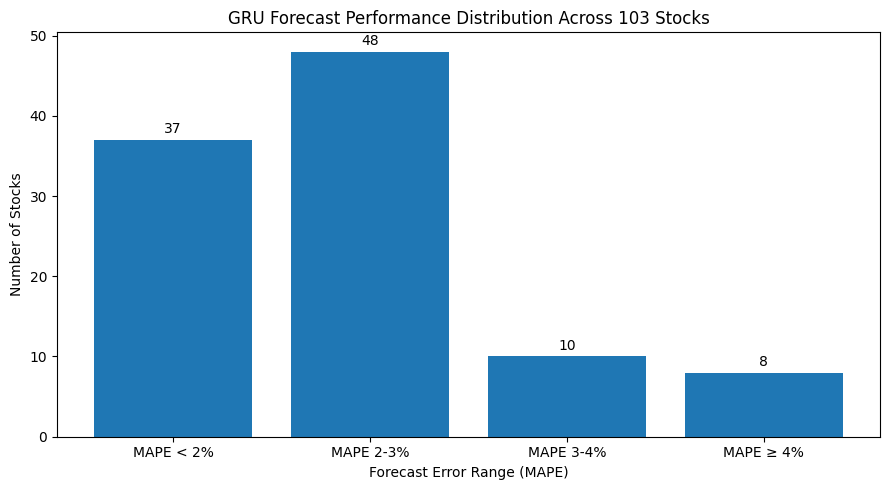

In [92]:
plt.figure(figsize=(9, 5))

bars = plt.bar(categories, counts)

plt.title("GRU Forecast Performance Distribution Across 103 Stocks")
plt.xlabel("Forecast Error Range (MAPE)")
plt.ylabel("Number of Stocks")

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        str(count),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(CHARTS_DIR, "mape_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

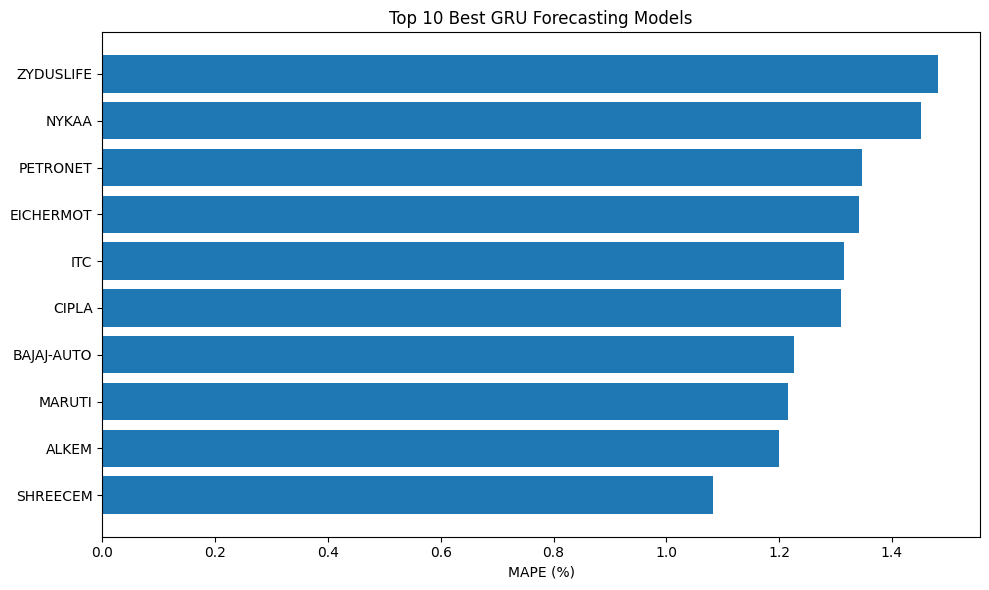

In [93]:
best_10_plot = final_results.sort_values("MAPE").head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    best_10_plot["Stock"],
    best_10_plot["MAPE"]
)

plt.title("Top 10 Best GRU Forecasting Models")
plt.xlabel("MAPE (%)")

plt.tight_layout()

plt.savefig(
    os.path.join(CHARTS_DIR, "top_10_best_mape.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

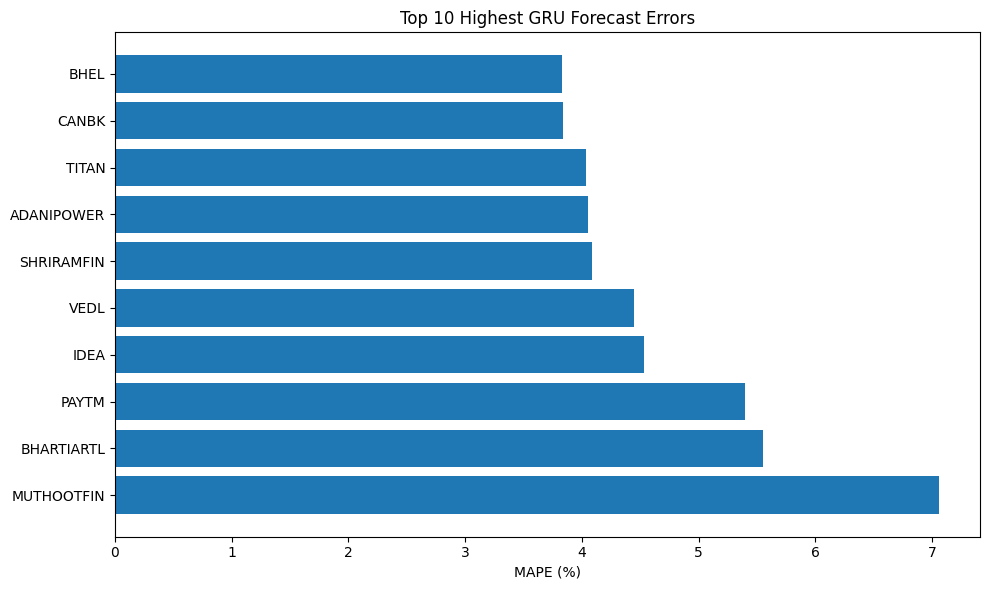

In [94]:
worst_10_plot = (
    final_results
    .sort_values("MAPE", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    worst_10_plot["Stock"],
    worst_10_plot["MAPE"]
)

plt.title("Top 10 Highest GRU Forecast Errors")
plt.xlabel("MAPE (%)")

plt.tight_layout()

plt.savefig(
    os.path.join(CHARTS_DIR, "top_10_worst_mape.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

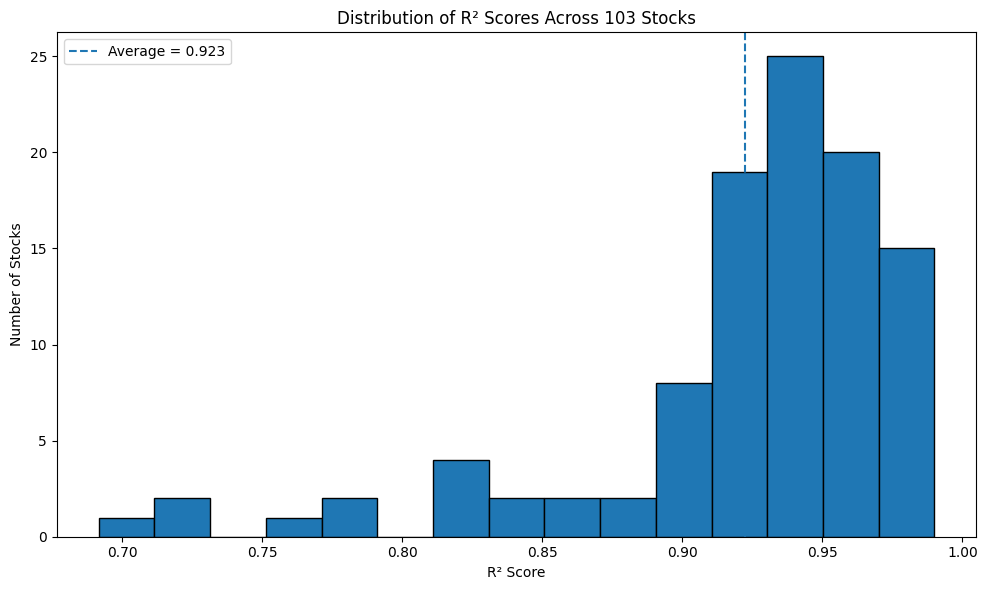

✓ All charts saved successfully


In [95]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_results["R2"],
    bins=15,
    edgecolor="black"
)

plt.axvline(
    final_results["R2"].mean(),
    linestyle="--",
    label=f"Average = {final_results['R2'].mean():.3f}"
)

plt.title("Distribution of R² Scores Across 103 Stocks")
plt.xlabel("R² Score")
plt.ylabel("Number of Stocks")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(CHARTS_DIR, "r2_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ All charts saved successfully")